## Assignment 2

- Leo Thomasson (#261167871)
- Ella Lukasiewicz (#261169106)
- Eve Rabin (#261160750)


### **Loading dataset**

In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [17]:
df = pd.read_csv("spambase.data", header=None) #put path to your file or put spambase.data in working direc
df.head()

,0,1,2,3,4,5,6,7,8,9,...,48,49,50,51,52,53,54,55,56,57
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


### **Inspecting the dataset**
There are 57 features and 1 Class (our target). All 57 features are continuous, while our Class is Binary. This represents the variable we are trying to predict from all of the features (1 for spam or 0 for not spam). Of the 57 features :

- 55 features of type float
  - 48 represent word frequencies (word_freq_...)
  - 6 represent char frequencies (char_freq_.)
  - 1 represents capital_run_length_average
- 2 features of type int
  - capital_run_length_longest, and capital_run_length_total

In [18]:
# get feature names
df_names = pd.read_csv(
    "spambase.names",
    header=None,
    comment="|",      # ignore comment lines
    skip_blank_lines=True
)

# Keep only lines that define features (contain :)
df_names = df_names[df_names[0].str.contains(":")]

# Extract feature names (text before :)
feature_names = df_names[0].str.split(":", expand=True)[0].tolist()

df.columns = feature_names + ["Class"]
df.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,Class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


### **Data Seperation**
No missing data, therefore no data cleaning is necessary. 

In [19]:
print(df.isna().sum().sum())  # total missing values
assert df.isna().sum().sum() == 0


0


We separate the dataset into feature matrix X and target vector y, converting them to NumPy arrays with appropriate numeric types to ensure compatibility with the learning algorithms.

In [20]:
X = df.iloc[:, :-1].to_numpy(dtype=np.float64)
y = df.iloc[:, -1].to_numpy(dtype=np.int64)

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (4601, 57)
y shape: (4601,)


There are 4601 samples with 57 features and 1 binary label.

Split data in 5% train and 95% test 

In [21]:
RANDOM_SEED = 2026
rng = np.random.default_rng(RANDOM_SEED)

n = X.shape[0]
indices = np.arange(n)
rng.shuffle(indices)

# 5% train
n_train = int(np.round(0.05 * n))

train_idx = indices[:n_train]
test_idx = indices[n_train:]

X_train = X[train_idx]
y_train = y[train_idx]

X_test = X[test_idx]
y_test = y[test_idx]

#before standardisation
X_train_raw = X_train.copy() # copy for task 2,3,4 
y_train_raw = y_train.copy() # copy for task 2,3,4 
X_test_raw  = X_test.copy() # copy for task 2, 3,4 
y_test_raw = y_test.copy() # copy for task 2, 3,4 

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])
print("Train spam rate:", y_train.mean())
print("Test spam rate:", y_test.mean())


Train size: 230
Test size: 4371
Train spam rate: 0.3869565217391304
Test spam rate: 0.39441775337451385


**Distribution of Feature Scales before Standardizing**

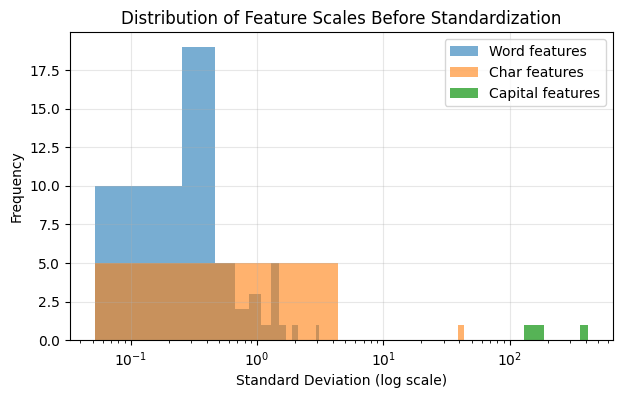

In [101]:
feature_stds = np.std(X_train_raw, axis=0)

word_mask = np.array([name.startswith("word_freq") for name in feature_names])
char_mask = np.array([name.startswith("char_freq") for name in feature_names])
capital_mask = np.array([name.startswith("capital") for name in feature_names])

plt.figure(figsize=(7,4))

plt.hist(feature_stds[word_mask], bins=15, alpha=0.6, label="Word features")
plt.hist(feature_stds[char_mask], bins=10, alpha=0.6, label="Char features")
plt.hist(feature_stds[capital_mask], bins=5, alpha=0.8, label="Capital features")

plt.xscale("log")   # THIS is the important change
plt.xlabel("Standard Deviation (log scale)")
plt.ylabel("Frequency")
plt.title("Distribution of Feature Scales Before Standardization")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Histogram of feature standard deviations computed on the training set (log-scale x-axis). Capitalization-based features exhibit standard deviations several orders of magnitude larger than word- and character-frequency features, highlighting strong scale heterogeneity and motivating feature standardization prior to optimization.

##### **Standardizing features**

Let's first evaluate variance and mean of each feature over the training data to determine the need for standardization. Variables are standardized when the mean is 0 and the std is 1.

In [22]:
# Mean of each feature
feature_means = df.mean()

# Variance of each feature (population variance)
feature_variances = df.var(ddof=0)

# Combine into a single DataFrame for easy inspection
stats = pd.DataFrame({
    "mean": feature_means,
    "variance": feature_variances
})

print(stats)

                                  mean       variance
word_freq_make                0.104553       0.093223
word_freq_address             0.213015       1.665222
word_freq_all                 0.280656       0.254105
word_freq_3d                  0.065425       1.946024
word_freq_our                 0.312223       0.452175
word_freq_over                0.095901       0.074963
word_freq_remove              0.114208       0.153193
word_freq_internet            0.105295       0.160823
word_freq_order               0.090067       0.077610
word_freq_mail                0.239413       0.415619
word_freq_receive             0.059824       0.040611
word_freq_will                0.541702       0.742363
word_freq_people              0.093930       0.090603
word_freq_report              0.058626       0.112324
word_freq_addresses           0.049205       0.066985
word_freq_free                0.248848       0.681784
word_freq_business            0.142586       0.197142
word_freq_email             

Clearly, the features have not been standardized. Therefore, to successfully clean our data we **standardize all 57 features**. However, in order to avoid data leakage, we standardize **ONLY** over our training set.

In [23]:

mu = X_train.mean(axis=0)                 # per-feature mean on TRAIN only
sigma = X_train.std(axis=0, ddof=0)       # per-feature std on TRAIN only
sigma[sigma == 0] = 1.0                   # avoid divide-by-zero

X_train_std = (X_train - mu) / sigma
X_test_std  = (X_test  - mu) / sigma


print("Train mean:", X_train_std.mean())
print("Train std:", X_train_std.std())

y_train = np.asarray(y_train).astype(int).reshape(-1)
y_test  = np.asarray(y_test).astype(int).reshape(-1)

Train mean: 4.3358824455231135e-18
Train std: 1.0


In [24]:
n_train, d = X_train_std.shape
print("n_train:", n_train, "features:", d)


n_train: 230 features: 57


As confirmed by the above snippets, we have a **Train mean** very close to 0 (to the order of ^-18) and a **Train std** = 1.0. Therefore, our data as whole has been standardized on the values found within our training set.

**Feature Sparsity Distribution**

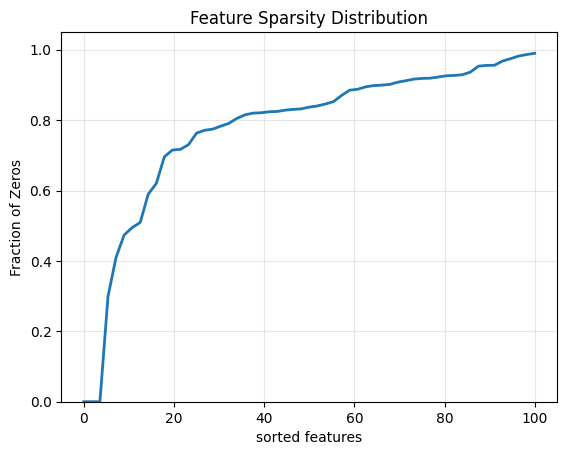

In [133]:
zero_fraction = np.mean(X == 0, axis=0)

sorted_sparsity = np.sort(zero_fraction)

percentiles = np.linspace(0, 100, len(sorted_sparsity))

plt.figure()
plt.plot(percentiles, sorted_sparsity, linewidth=2)
plt.xlabel("sorted features")
plt.ylabel("Fraction of Zeros")
plt.title("Feature Sparsity Distribution")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.show()

## Full Correlation matrix 

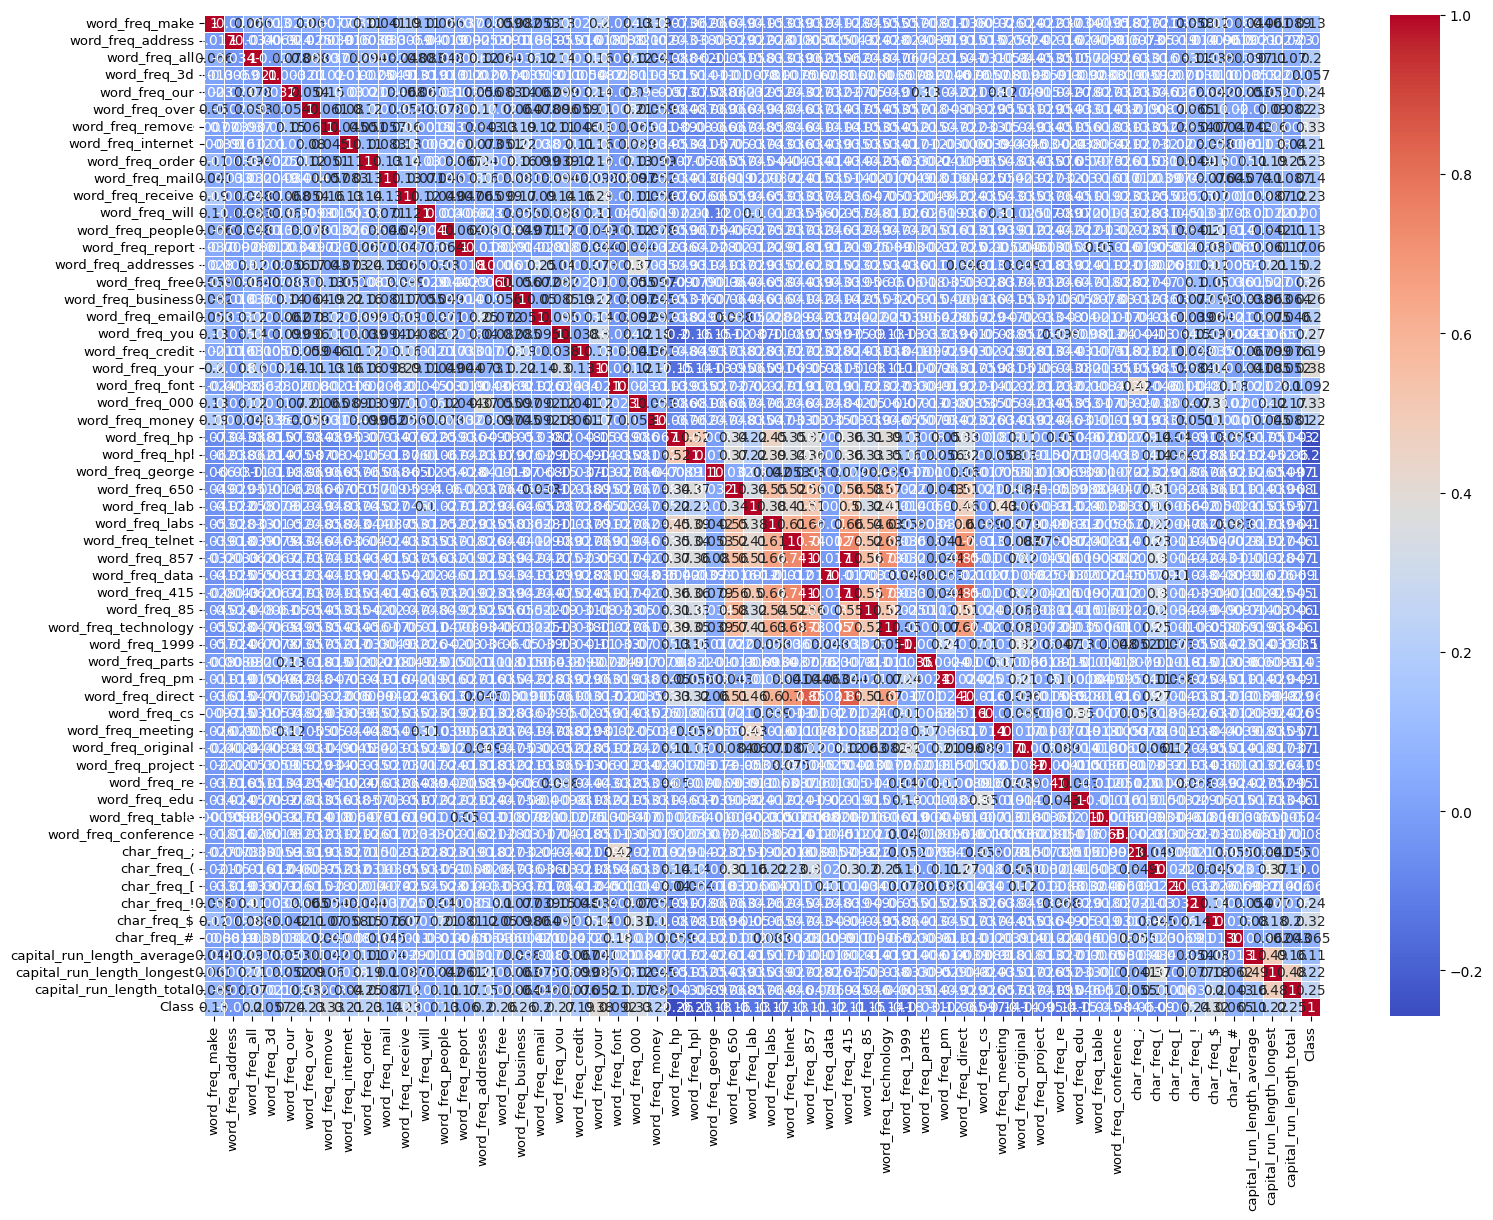

In [25]:
df_train = pd.DataFrame(X_train, columns=feature_names)
df_train['class'] = y_train
corr = df_train.corr()

#correlation Matrix to better understand releationships between features
plt.figure(figsize=(18,13))
corr = df.corr()
sns.heatmap(corr, xticklabels=corr.columns.values, yticklabels=corr.columns.values, linewidths=.5, cmap='coolwarm', annot=True)
plt.xticks(fontsize=9.5)
plt.yticks(fontsize=9.5)
plt.show()

In order to properly visualize features that are more correlated than others, we can select the few significant ones that can be seen around the center of the above correlation matrix. 

## Zoomed in Correlation Matrix

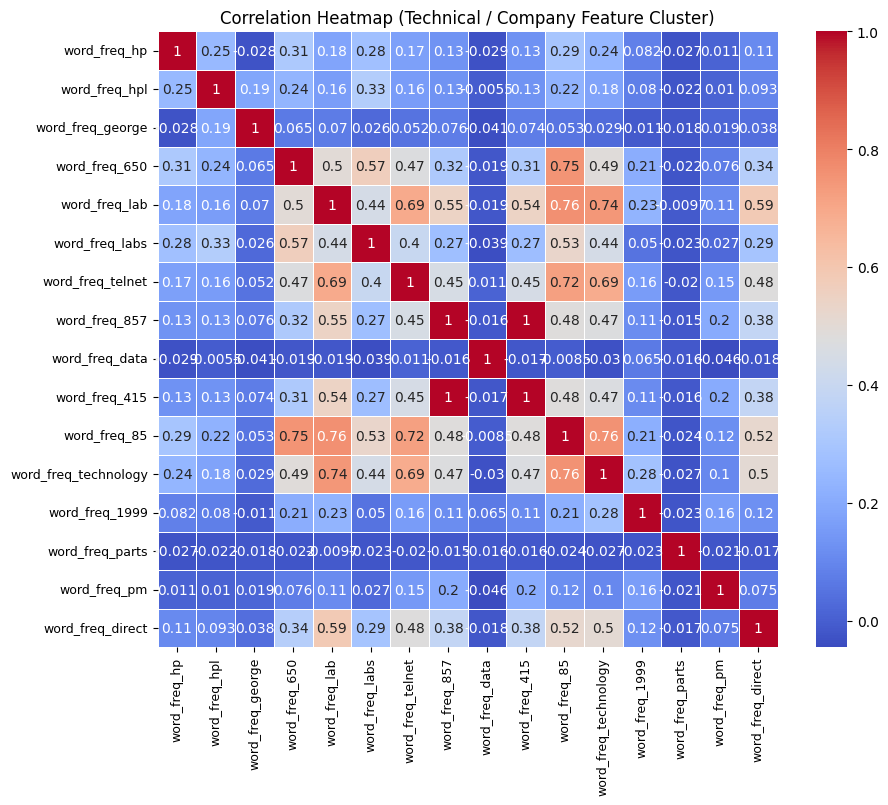

In [26]:
selected_features = [
    'word_freq_hp',
    'word_freq_hpl',
    'word_freq_george',
    'word_freq_650',
    'word_freq_lab',
    'word_freq_labs',
    'word_freq_telnet',
    'word_freq_857',
    'word_freq_data',
    'word_freq_415',
    'word_freq_85',
    'word_freq_technology',
    'word_freq_1999',
    'word_freq_parts',
    'word_freq_pm',
    'word_freq_direct'
]

df_zoom_cluster = df_train[selected_features]
plt.figure(figsize=(10, 8))

corr_cluster = df_zoom_cluster.corr()

sns.heatmap(
    corr_cluster,
    xticklabels=corr_cluster.columns.values,
    yticklabels=corr_cluster.columns.values,
    linewidths=.5,
    cmap='coolwarm',
    annot=True
)

plt.xticks(rotation=90, fontsize=9)
plt.yticks(fontsize=9)
plt.title("Correlation Heatmap (Technical / Company Feature Cluster)")
plt.show()


From our zoomed-in correlation matrix, the key observation is **multicollinearity**. Looking at the highly correlated feature pairs, we find:

- word_freq_lab <-> word_freq_85: 0.76
- word_freq_650 <-> word_freq_85: 0.75
- word_freq_telnet <-> word_freq_lab: 0.69
- word_freq_857 <-> word_freq_415: **effectively 1.0**

This is important because in theory L1 regularization remove features that have multicollinearity and low relevance. As we develop our regularization models we can come back to this matrix to further understand selections made.

In [27]:
print(df_train[selected_features + ['class']].corr()['class'])

word_freq_hp           -0.268680
word_freq_hpl          -0.216655
word_freq_george       -0.206401
word_freq_650          -0.202223
word_freq_lab          -0.213565
word_freq_labs         -0.158786
word_freq_telnet       -0.197248
word_freq_857          -0.152552
word_freq_data         -0.147572
word_freq_415          -0.144239
word_freq_85           -0.237113
word_freq_technology   -0.228551
word_freq_1999         -0.245466
word_freq_parts        -0.062838
word_freq_pm           -0.192602
word_freq_direct       -0.147314
class                   1.000000
Name: class, dtype: float64


# Task 1: Logistic Regression with SGD

**Logistic Regression model:**

Convention used: L_reg(w,b) = L(w,b) + 𝜆/2 (||w||^2)2. So the L2 gradient contribution is 𝜆w.



Below is our implementation of Logistic Regression using Stochastic Gradient Descent. 

In [28]:
def sigmoid(z):
    # stable sigmoid
    z = np.clip(z, -35, 35)
    return 1.0 / (1.0 + np.exp(-z))

def cross_entropy(y, p, eps=1e-12):
    p = np.clip(p, eps, 1 - eps)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

def weight_norm(w):
    return np.linalg.norm(w)

In [29]:
class LogisticRegressionSGD:

    def __init__(self, lr=1e-2, epochs=100, batch_size=16, l2=0.0, seed=RANDOM_SEED): #default parameters
        self.lr = float(lr)
        self.epochs = int(epochs)
        self.batch_size = int(batch_size)
        self.l2 = float(l2)
        self.seed = int(seed)

        self.w = None
        self.b = None

        # histories
        self.train_ce_history = []
        self.test_ce_history = []
        self.train_acc_history = []
        self.test_acc_history = []
        self.step_ce_history = []     
        self.w_norm_history = []      

    def fit(self, X, y, X_test=None, y_test=None):
        X = np.asarray(X, dtype=np.float64)
        y = np.asarray(y, dtype=np.float64).reshape(-1)
        n, d = X.shape

        rng_local = np.random.default_rng(self.seed) 

        self.w = np.zeros(d, dtype=np.float64)
        self.b = 0.0

        self.train_ce_history = []
        self.test_ce_history = []
        self.train_acc_history = []
        self.test_acc_history = []
        self.step_ce_history = []
        self.w_norm_history = []

        for ep in range(self.epochs):
            idx = rng_local.permutation(n) # shuffle after each epoch
            Xs, ys = X[idx], y[idx]

            # mini-batch updates
            for start in range(0, n, self.batch_size):
                end = min(start + self.batch_size, n)
                Xb, yb = Xs[start:end], ys[start:end]

                z = Xb @ self.w + self.b
                p = sigmoid(z)

                diff = (p - yb)
                B = len(yb)

                grad_w = (Xb.T @ diff) / B + self.l2 * self.w
                grad_b = np.sum(diff) / B

                self.w -= self.lr * grad_w
                self.b -= self.lr * grad_b

                self.step_ce_history.append(cross_entropy(yb, p))

            # end epoch: evaluate full train
            p_train = sigmoid(X @ self.w + self.b)
            yhat_train = (p_train >= 0.5).astype(int)

            self.train_ce_history.append(cross_entropy(y, p_train))
            self.train_acc_history.append(accuracy(y, yhat_train))
            self.w_norm_history.append(weight_norm(self.w)) # to see effects of L2 regularisation 

            # full test if given
            if X_test is not None and y_test is not None:
                Xt = np.asarray(X_test, dtype=np.float64)
                yt = np.asarray(y_test, dtype=np.float64).reshape(-1)

                p_test = sigmoid(Xt @ self.w + self.b)
                yhat_test = (p_test >= 0.5).astype(int)

                self.test_ce_history.append(cross_entropy(yt, p_test))
                self.test_acc_history.append(accuracy(yt, yhat_test))

        return self

    def predict_proba(self, X):
        X = np.asarray(X, dtype=np.float64)
        return sigmoid(X @ self.w + self.b)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

**Preliminary Analysis**

Firstly, we compare the effects of choosing various hyperparameter values recommended values in the assignment. This includes:

- no regularization vs L2 regularization
- SGD vs mini-batch (the batch size effect)


In [30]:
# Default parameters
BASE_B = 16
BASE_LR = 1e-2
BASE_EPOCHS = 100

L2_REC = 1e-3   # recommended in assignment
L2_STRONG = 1e-2 # another test
L2_NONE = 0.0

# Baseline: compare no-reg vs L2 at recommended lambda + other lambda
model_base_noreg    = LogisticRegressionSGD(lr=BASE_LR, epochs=BASE_EPOCHS, batch_size=BASE_B, l2=L2_NONE,   seed=RANDOM_SEED)
model_base_l2_rec   = LogisticRegressionSGD(lr=BASE_LR, epochs=BASE_EPOCHS, batch_size=BASE_B, l2=L2_REC,    seed=RANDOM_SEED)
model_base_l2_strong= LogisticRegressionSGD(lr=BASE_LR, epochs=BASE_EPOCHS, batch_size=BASE_B, l2=L2_STRONG, seed=RANDOM_SEED)

model_base_noreg.fit(X_train_std, y_train, X_test_std, y_test)
model_base_l2_rec.fit(X_train_std, y_train, X_test_std, y_test)
model_base_l2_strong.fit(X_train_std, y_train, X_test_std, y_test)

# Batch-size effect (SGD vs mini-batch) 
B_LIST = [1, 16, 64]
models_batch = {}
for B in B_LIST:
    m = LogisticRegressionSGD(lr=BASE_LR, epochs=BASE_EPOCHS, batch_size=B, l2=0.0, seed=RANDOM_SEED)
    m.fit(X_train_std, y_train, X_test_std, y_test)
    models_batch[B] = m


Once modeled, we can plot theses values in order to conduct a preliminary analysis. We are only modeling certain parameters mostly to determine the effects of L2 regularization. 

Further on we will tune the hyperparameters to choose an ideal model for fitting our data. This will be done by testing a much larger combination of hyperparameters.

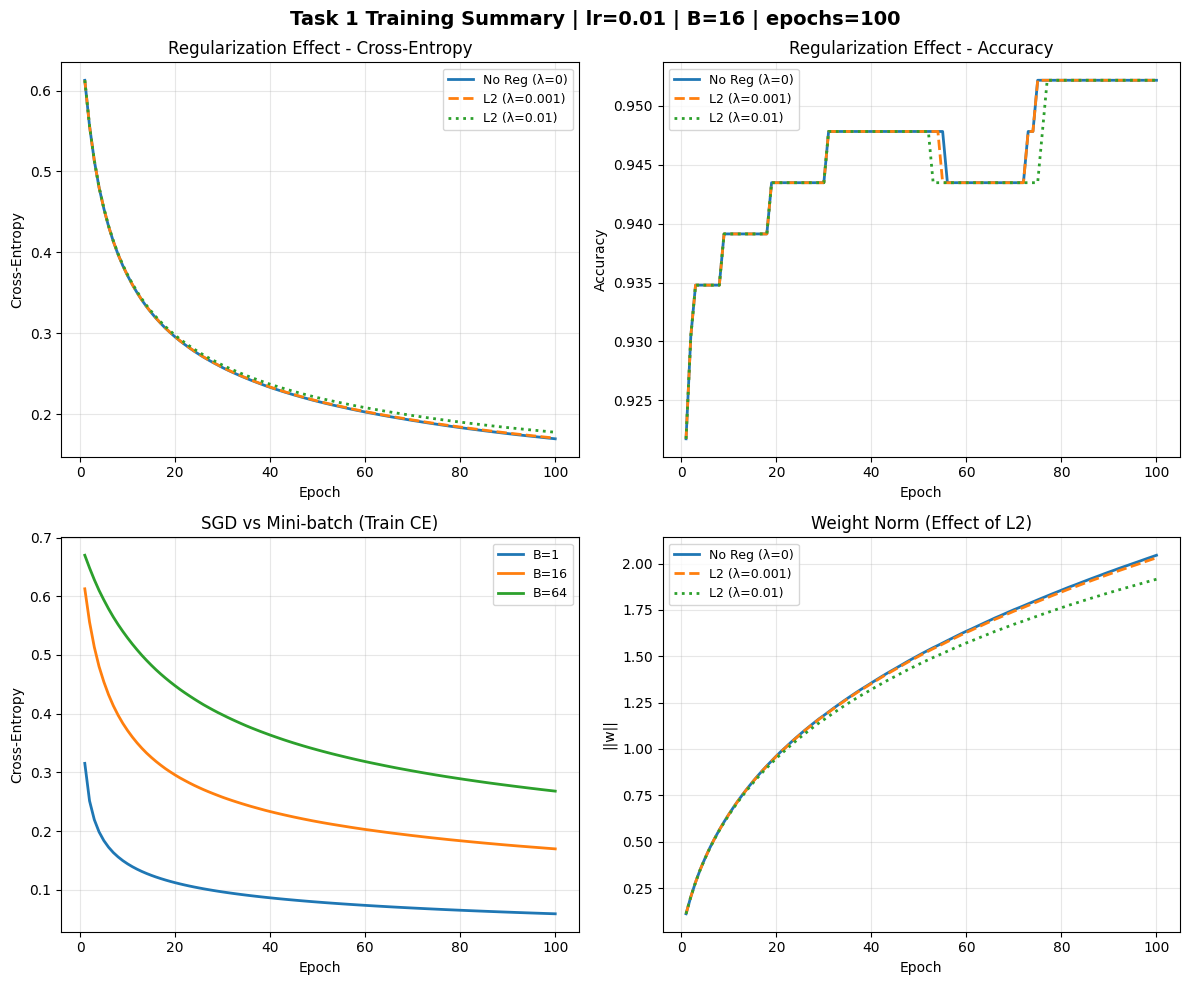

In [31]:

epochs = np.arange(1, BASE_EPOCHS + 1)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

ax = axes[0, 0]
ax.plot(epochs, model_base_noreg.train_ce_history,
        label='No Reg (λ=0)', linewidth=2)
ax.plot(epochs, model_base_l2_rec.train_ce_history,
        label=f'L2 (λ={L2_REC})', linestyle='--', linewidth=2)
ax.plot(epochs, model_base_l2_strong.train_ce_history,
        label=f'L2 (λ={L2_STRONG})', linestyle=':', linewidth=2)


ax.set_title('Regularization Effect - Cross-Entropy')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cross-Entropy')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)


ax = axes[0, 1]
ax.plot(epochs, model_base_noreg.train_acc_history,
        label='No Reg (λ=0)', linewidth=2)
ax.plot(epochs, model_base_l2_rec.train_acc_history,
        label=f'L2 (λ={L2_REC})', linestyle='--', linewidth=2)
ax.plot(epochs, model_base_l2_strong.train_acc_history,
        label=f'L2 (λ={L2_STRONG})', linestyle=':', linewidth=2)

ax.set_title('Regularization Effect - Accuracy')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)


ax = axes[1, 0]
for B in sorted(models_batch.keys()):
    ax.plot(epochs, models_batch[B].train_ce_history,
            label=f'B={B}', linewidth=2)

ax.set_title('SGD vs Mini-batch (Train CE)')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cross-Entropy')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)


ax = axes[1, 1]
ax.plot(epochs, model_base_noreg.w_norm_history,
        label='No Reg (λ=0)', linewidth=2)
ax.plot(epochs, model_base_l2_rec.w_norm_history,
        label=f'L2 (λ={L2_REC})', linestyle='--', linewidth=2)
ax.plot(epochs, model_base_l2_strong.w_norm_history,
        label=f'L2 (λ={L2_STRONG})', linestyle=':', linewidth=2)

ax.set_title('Weight Norm (Effect of L2)')
ax.set_xlabel('Epoch')
ax.set_ylabel('||w||')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)


plt.suptitle(
    f'Task 1 Training Summary | lr={BASE_LR} | B={BASE_B} | epochs={BASE_EPOCHS}',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()


Training cross-entropy decreases smoothly across epochs, indicating stable optimization with the chosen learning rate. L2 regularization slightly increases training loss but effectively constrains weight growth, as reflected in the smaller weight norms. Smaller batch sizes (B=1) converge faster due to more frequent updates, while larger batches produce smoother but slower convergence. Overall, the observed behavior matches theoretical expectations for SGD-trained logistic regression.

Stability-wise it is clear that our models are all stable. No oscillations or divergence are observed from these graphs. This indicates smooth gradient implementation.

It is important to evaluate these models on the testing data in order to determine if there has been overfitting.

In [ ]:
def summarize_model_table(models_dict, X_train, y_train, X_test, y_test):

    rows = []

    for name, m in models_dict.items():
        # Cross-entropy from history
        train_ce = m.train_ce_history[-1]
        test_ce = m.test_ce_history[-1]

        # Accuracy (computed to be safe)
        yhat_train = m.predict(X_train)
        yhat_test  = m.predict(X_test)

        train_acc = np.mean(yhat_train == y_train)
        test_acc  = np.mean(yhat_test == y_test)

        # Weight norm (optional but useful for L2 discussion)
        w_norm = np.linalg.norm(m.w)

        rows.append({
            "Model": name,
            "Train CE": train_ce,
            "Test CE": test_ce,
            "Train Acc": train_acc,
            "Test Acc": test_acc,
            "Weight Norm": w_norm
        })

    df = pd.DataFrame(rows)
    return df

models_dict = {
    "No reg (λ=0)": model_base_noreg,
    "L2 (λ=1e-3)": model_base_l2_rec,
    "L2 (λ=1e-2)": model_base_l2_strong
}

results_df = summarize_model_table(
    models_dict,
    X_train_std, y_train,
    X_test_std, y_test
)

results_df.round(4)


,Model,Train CE,Test CE,Train Acc,Test Acc,Weight Norm
0,No reg (λ=0),0.1698,0.3020,0.9522,0.9064,2.0447
1,L2 (λ=1e-3),0.1706,0.3019,0.9522,0.9064,2.0311
2,L2 (λ=1e-2),0.1779,0.3015,0.9522,0.9080,1.9155


Increasing λ slightly raises training loss but reduces weight magnitude, confirming the effect of L2 regularization. Moderate regularization (λ = 1e-2) yields the best test performance, with the lowest Test CE.

This can be confirmed through plotting the SGD convergence for different learning rates.


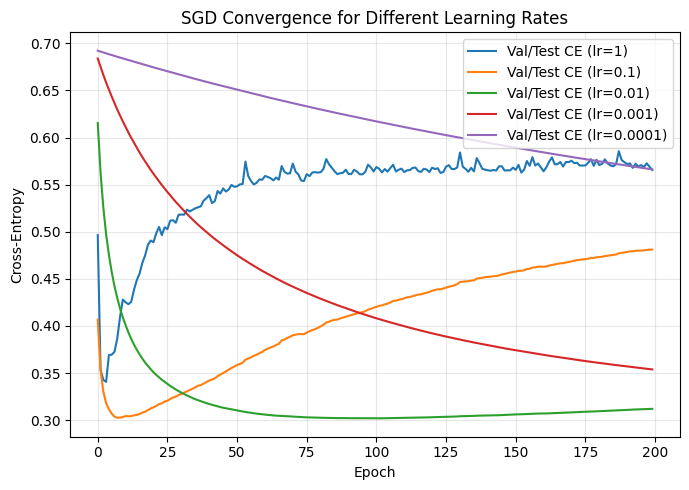

In [ ]:
LR_LIST = [1,1e-1, 1e-2, 1e-3, 1e-4]
histories = {}

for lr in LR_LIST:
    m = LogisticRegressionSGD(lr=lr, epochs=200, batch_size=16, l2=1e-3, seed=2026)
    m.fit(Xtr_std, ytr, Xte_std, yte)  # use val only for monitoring, not for selection
    histories[lr] = (m.train_ce_history, m.test_ce_history)

plt.figure(figsize=(7,5))
for lr in LR_LIST:
    plt.plot(histories[lr][1], label=f"Val/Test CE (lr={lr:g})")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy")
plt.title("SGD Convergence for Different Learning Rates")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


### SGD Convergence for Different Learning Rates

This figure shows validation cross-entropy across epochs for different learning rates.

A very large learning rate (0.1) decreases quickly at first but then diverges, leading to increasing error due to unstable updates. Moderate learning rates (0.03 and 0.01) achieve faster convergence and reach lower validation error, indicating a better balance between speed and stability. A very small learning rate (0.003) converges smoothly but more slowly.

This highlights the importance of learning rate selection: too large leads to instability, too small slows convergence, and intermediate values achieve the best optimization performance. We will be able to further to tune, and have a more complete analysis for each hyperparameter as all combinations of recommended hyperparameters will be tested with K-Fold Cross Validation.

### Comparing SGD and Adam

As an additional experiment, we compare vanilla Stochastic Gradient Descent (SGD) with the Adam optimizer to examine whether adaptive updates influence convergence behavior or generalization in this logistic regression setting.

Unlike SGD, which uses a fixed global learning rate, Adam incorporates adaptive moment estimates of first and second-order gradients to scale parameter updates individually. This can improve optimization speed and stability in some settings. Here, we implement Adam from scratch and compare its behavior to SGD under the same batch size, regularization strength, and number of epochs, using optimizer-specific learning rates to ensure stable convergence.

In [130]:

def sigmoid(z):
    z = np.clip(z, -35, 35)
    return 1.0 / (1.0 + np.exp(-z))

def cross_entropy(y, p, eps=1e-12):
    p = np.clip(p, eps, 1 - eps)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

def weight_norm(w):
    return np.linalg.norm(w)


# Adam implementation
class LogisticRegressionAdam:
    def __init__(self, lr=1e-3, epochs=100, batch_size=16, l2=0.0,
                 beta1=0.9, beta2=0.999, eps=1e-8, seed=2026):
        self.lr = float(lr)
        self.epochs = int(epochs)
        self.batch_size = int(batch_size)
        self.l2 = float(l2)
        self.beta1 = float(beta1)
        self.beta2 = float(beta2)
        self.eps = float(eps)
        self.seed = int(seed)

        self.w = None
        self.b = None

        # histories (match your SGD class)
        self.train_ce_history = []
        self.test_ce_history = []
        self.train_acc_history = []
        self.test_acc_history = []
        self.step_ce_history = []
        self.w_norm_history = []

    def fit(self, X, y, X_test=None, y_test=None):
        X = np.asarray(X, dtype=np.float64)
        y = np.asarray(y, dtype=np.float64).reshape(-1)
        n, d = X.shape

        rng_local = np.random.default_rng(self.seed)

        # params
        self.w = np.zeros(d, dtype=np.float64)
        self.b = 0.0

        # Adam state
        mw = np.zeros_like(self.w)
        vw = np.zeros_like(self.w)
        mb = 0.0
        vb = 0.0

        # reset histories
        self.train_ce_history = []
        self.test_ce_history = []
        self.train_acc_history = []
        self.test_acc_history = []
        self.step_ce_history = []
        self.w_norm_history = []

        t = 0  # Adam time step (per update)

        for ep in range(self.epochs):
            idx = rng_local.permutation(n)
            Xs, ys = X[idx], y[idx]

            for start in range(0, n, self.batch_size):
                end = min(start + self.batch_size, n)
                Xb, yb = Xs[start:end], ys[start:end]

                z = Xb @ self.w + self.b
                p = sigmoid(z)

                diff = (p - yb)
                B = len(yb)

                # gradients (same as your SGD convention)
                grad_w = (Xb.T @ diff) / B + self.l2 * self.w
                grad_b = np.sum(diff) / B

                # Adam update
                t += 1
                mw = self.beta1 * mw + (1 - self.beta1) * grad_w
                vw = self.beta2 * vw + (1 - self.beta2) * (grad_w * grad_w)

                mb = self.beta1 * mb + (1 - self.beta1) * grad_b
                vb = self.beta2 * vb + (1 - self.beta2) * (grad_b * grad_b)

                mw_hat = mw / (1 - self.beta1 ** t)
                vw_hat = vw / (1 - self.beta2 ** t)

                mb_hat = mb / (1 - self.beta1 ** t)
                vb_hat = vb / (1 - self.beta2 ** t)

                self.w -= self.lr * mw_hat / (np.sqrt(vw_hat) + self.eps)
                self.b -= self.lr * mb_hat / (np.sqrt(vb_hat) + self.eps)

                self.step_ce_history.append(cross_entropy(yb, p))

            # end epoch eval
            p_train = sigmoid(X @ self.w + self.b)
            yhat_train = (p_train >= 0.5).astype(int)

            self.train_ce_history.append(cross_entropy(y, p_train))
            self.train_acc_history.append(accuracy(y, yhat_train))
            self.w_norm_history.append(weight_norm(self.w))

            if X_test is not None and y_test is not None:
                Xt = np.asarray(X_test, dtype=np.float64)
                yt = np.asarray(y_test, dtype=np.float64).reshape(-1)

                p_test = sigmoid(Xt @ self.w + self.b)
                yhat_test = (p_test >= 0.5).astype(int)

                self.test_ce_history.append(cross_entropy(yt, p_test))
                self.test_acc_history.append(accuracy(yt, yhat_test))

        return self

    def predict_proba(self, X):
        X = np.asarray(X, dtype=np.float64)
        return sigmoid(X @ self.w + self.b)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)


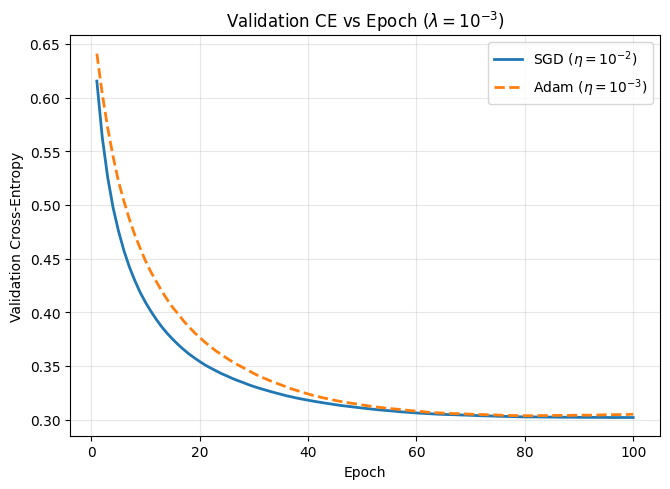

,Model,Train CE (final),Val CE (final),Train Acc (final),Val Acc (final),||w||2 (final)
0,SGD,0.1706,0.3019,0.9522,0.9064,2.0311
1,Adam,0.1539,0.3050,0.9652,0.9000,2.3543


In [132]:

LAMBDA_FOR_OPT = 1e-3   
# Learning rates: Adam typically uses a smaller lr than SGD
SGD_LR  = 1e-2
ADAM_LR = 1e-3

# Train both optimizers under the SAME batch size/epochs/l2
sgd = LogisticRegressionSGD(
    lr=SGD_LR, epochs=BASE_EPOCHS, batch_size=BASE_B, l2=LAMBDA_FOR_OPT, seed=RANDOM_SEED
)
adam = LogisticRegressionAdam(
    lr=ADAM_LR, epochs=BASE_EPOCHS, batch_size=BASE_B, l2=LAMBDA_FOR_OPT, seed=RANDOM_SEED
)

sgd.fit(X_train_std, y_train,  X_test_std, y_test)
adam.fit(X_train_std, y_train,  X_test_std, y_test)

epochs = np.arange(1, BASE_EPOCHS + 1)

plt.figure(figsize=(6.8, 5))

plt.plot(
    epochs,
    sgd.test_ce_history,
    label=r"SGD ($\eta=10^{-2}$)",
    linewidth=2
)

plt.plot(
    epochs,
    adam.test_ce_history,
    label=r"Adam ($\eta=10^{-3}$)",
    linewidth=2,
    linestyle="--"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Cross-Entropy")
plt.title(r"Validation CE vs Epoch ($\lambda=10^{-3}$)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
plt.close()


def summarize_one(name, model, Xtr, ytr, Xva, yva):
    p_tr = model.predict_proba(Xtr)
    p_va = model.predict_proba(Xva)

    yhat_tr = (p_tr >= 0.5).astype(int)
    yhat_va = (p_va >= 0.5).astype(int)

    return {
        "Model": name,
        "Train CE (final)": cross_entropy(ytr, p_tr),
        "Val CE (final)": cross_entropy(yva, p_va),
        "Train Acc (final)": np.mean(yhat_tr == ytr),
        "Val Acc (final)": np.mean(yhat_va == yva),
        "||w||2 (final)": np.linalg.norm(model.w),
    }

summary_df = pd.DataFrame([
    summarize_one("SGD", sgd, X_train_std, y_train,  X_test_std, y_test),
    summarize_one("Adam", adam, X_train_std, y_train,  X_test_std, y_test)])

display(summary_df.round(4))

## Observations: SGD vs Adam

Adam achieves slightly lower training cross-entropy and converges marginally faster than SGD. However, validation performance remains nearly identical across training, indicating no meaningful generalization advantage in this convex logistic regression problem.

These results suggest that while adaptive optimization can accelerate convergence, optimizer choice has limited impact on final performance in this small-data, well-conditioned setting.

# Task 2: Hyperparameter Tuning with K-Fold Cross-Validation

**K-FOLD Cross Validation:** is used to evaluate models by dividing the dataset into K equal-sized folds. The model is trained K-1 times, and each time uses the remaining fold for validation. This allows for every point in our training set to be used for training and testing.

This is an effective way for detecting overfitting within our testing data. 


In [33]:
def kfold_indices(n, k=3, seed=2026, shuffle=True):
    rng = np.random.default_rng(seed)
    idx = np.arange(n)
    if shuffle:
        rng.shuffle(idx)
    folds = np.array_split(idx, k)
    for i in range(k):
        val_idx = folds[i]
        train_idx = np.concatenate([folds[j] for j in range(k) if j != i])
        yield train_idx, val_idx

def standardize_train_val(X_tr, X_val):
    mu = X_tr.mean(axis=0)
    sigma = X_tr.std(axis=0, ddof=0)
    sigma[sigma == 0] = 1.0
    return (X_tr - mu) / sigma, (X_val - mu) / sigma

In [34]:
def cv_eval_setting(
    X_train_raw, y_train_raw,
    k, lr, batch_size, epochs,
    l2=0.0,
    seed=2026
):
    fold_train_ce, fold_val_ce = [], []
    fold_train_acc, fold_val_acc = [], []

    X_train_raw = np.asarray(X_train_raw, dtype=np.float64)
    y_train_raw = np.asarray(y_train_raw).astype(int).reshape(-1)

    n = X_train_raw.shape[0]

    for tr_idx, val_idx in kfold_indices(n, k=k, seed=seed, shuffle=True):
        X_tr_raw = X_train_raw[tr_idx]
        y_tr     = y_train_raw[tr_idx]
        X_val_raw = X_train_raw[val_idx]
        y_val     = y_train_raw[val_idx]

        X_tr_std, X_val_std = standardize_train_val(X_tr_raw, X_val_raw)

        m = LogisticRegressionSGD(
            lr=lr,
            epochs=epochs,
            batch_size=batch_size,
            l2=l2,
            seed=seed,
        )

        m.fit(X_tr_std, y_tr, X_val_std, y_val)

        fold_train_ce.append(m.train_ce_history[-1])
        fold_val_ce.append(m.test_ce_history[-1])
        fold_train_acc.append(m.train_acc_history[-1])
        fold_val_acc.append(m.test_acc_history[-1])

    return {
        "K": int(k),
        "B": int(batch_size),
        "lr": float(lr),
        "epochs": int(epochs),
        "lambda": float(l2),

        "train_CE_mean": float(np.mean(fold_train_ce)),
        "train_CE_std":  float(np.std(fold_train_ce, ddof=1)) if k > 1 else 0.0,
        "val_CE_mean":   float(np.mean(fold_val_ce)),
        "val_CE_std":    float(np.std(fold_val_ce, ddof=1)) if k > 1 else 0.0,

        "train_acc_mean": float(np.mean(fold_train_acc)),
        "train_acc_std":  float(np.std(fold_train_acc, ddof=1)) if k > 1 else 0.0,
        "val_acc_mean":   float(np.mean(fold_val_acc)),
        "val_acc_std":    float(np.std(fold_val_acc, ddof=1)) if k > 1 else 0.0,
    }


We sweep through every possible combination of recommended hyperparameters, as well as a range of K (from 3 to 8 folds) in order to determine the best implementation.

This is a computationally heavy task with the advantage of understanding to the furthest extent the value and role of each hyperparameter.

In [ ]:

K_LIST = list(range(3, 8))    # K range
batch_grid = [4, 8, 12, 16, 24, 32, 40, 50, 64, 96] # removed 1 for training purposes
lr_grid    = [1,1e-1, 1e-2, 1e-3, 1e-4]
epoch_grid = [50, 60, 75, 85, 100, 125, 150, 175, 200, 250, 300]


L2_FOR_TASK2 = 1e-3
cv_results = []

total = (
    len(K_LIST)
    * len(batch_grid)
    * len(lr_grid)
    * len(epoch_grid)
)

done = 0

for K in K_LIST:
    for B in batch_grid:
        for lr in lr_grid:
            for ep in epoch_grid:

                res = cv_eval_setting(
                X_train_raw=X_train_raw,
                y_train_raw=y_train_raw,
                k=K, lr=lr, batch_size=B, epochs=ep,
                l2=L2_FOR_TASK2,
                seed=RANDOM_SEED                    
                )
                
                cv_results.append(res)

                done += 1
                if done % 100 == 0 or done == total:
                    print(f"Progress: {done}/{total}")


Progress: 100/2750
Progress: 200/2750
Progress: 300/2750
Progress: 400/2750
Progress: 500/2750
Progress: 600/2750
Progress: 700/2750
Progress: 800/2750
Progress: 900/2750
Progress: 1000/2750
Progress: 1100/2750
Progress: 1200/2750
Progress: 1300/2750
Progress: 1400/2750
Progress: 1500/2750
Progress: 1600/2750
Progress: 1700/2750
Progress: 1800/2750
Progress: 1900/2750
Progress: 2000/2750
Progress: 2100/2750
Progress: 2200/2750
Progress: 2300/2750
Progress: 2400/2750
Progress: 2500/2750
Progress: 2600/2750
Progress: 2700/2750
Progress: 2750/2750


Once all models evaluated, we can easily find the best model by selecting the one with the smallest Cross Entropy mean. 

In [106]:
#to see full CV table:
print(cv_df)

     K   B      lr  epochs  lambda  train_CE_mean  train_CE_std  val_CE_mean  \
0    6   4  1.0000      50   0.001       0.043380      0.009546     0.453208   
1    6   4  1.0000      60   0.001       0.040240      0.005875     0.457197   
2    6   4  1.0000      75   0.001       0.036689      0.003940     0.454063   
3    6   4  1.0000      85   0.001       0.035750      0.002864     0.432456   
4    6   4  1.0000     100   0.001       0.040497      0.005982     0.430550   
..  ..  ..     ...     ...     ...            ...           ...          ...   
545  6  96  0.0001     150   0.001       0.674782      0.000880     0.673644   
546  6  96  0.0001     175   0.001       0.671847      0.001015     0.670583   
547  6  96  0.0001     200   0.001       0.668948      0.001147     0.667572   
548  6  96  0.0001     250   0.001       0.663251      0.001403     0.661698   
549  6  96  0.0001     300   0.001       0.657687      0.001647     0.656011   

     val_CE_std  train_acc_mean  train_

In [107]:

cv_df = pd.DataFrame(cv_results)

best_overall = cv_df.loc[[cv_df['val_CE_mean'].idxmin()]]


cols = [
    "K", "B", "lr", "epochs", "lambda",
    "train_CE_mean", "train_CE_std",
    "val_CE_mean", "val_CE_std",
    "train_acc_mean", "train_acc_std",
    "val_acc_mean", "val_acc_std"
]

best_table = best_overall[cols].round(4)

print("\nBest overall setting: \n")

print(best_table.to_string(index=False))

best_per_k = (
    cv_df.loc[
        cv_df.groupby('K')['val_CE_mean'].idxmin()
    ]
    .reset_index(drop=True)
)

print("\nBest setting for each K:")
print(best_per_k)

best_k_row = best_per_k.loc[best_per_k['val_CE_mean'].idxmin()].copy()

best_k = int(best_k_row['K'])

print("\nBest K selected (lowest validation CE): ")

print(
    f"K={best_k} | "
    f"B={int(best_k_row['B'])}, "
    f"lr={best_k_row['lr']:g}, "
    f"epochs={int(best_k_row['epochs'])}, "
    f"val_CE={best_k_row['val_CE_mean']:.4f}, "
    f"val_acc={best_k_row['val_acc_mean']:.4f}"
)




Best overall setting: 

 K  B   lr  epochs  lambda  train_CE_mean  train_CE_std  val_CE_mean  val_CE_std  train_acc_mean  train_acc_std  val_acc_mean  val_acc_std
 6 50 0.01     250   0.001         0.1871        0.0093       0.3173      0.1203          0.9513         0.0092        0.9127       0.0363

Best setting for each K:
   K   B     lr  epochs  lambda  train_CE_mean  train_CE_std  val_CE_mean  \
0  3  50  0.100      50   0.001       0.135372      0.010516     0.337762   
1  4   8  0.001     300   0.001       0.208351      0.017035     0.339627   
2  5  12  0.010      60   0.001       0.186606      0.015842     0.329254   
3  6  50  0.010     250   0.001       0.187061      0.009318     0.317298   
4  7  96  0.010     300   0.001       0.194857      0.011869     0.337579   

   val_CE_std  train_acc_mean  train_acc_std  val_acc_mean  val_acc_std  
0    0.130081        0.973899       0.006600      0.912793     0.050244  
1    0.091164        0.955076       0.011965      0.895417  

Through extensive Cross Validation, we can confidently select the best hyperparameter settings, such that: 

K=6, B=50, lr=0.01, epochs=250

**Which parameter mattered most and why?**

To answer this question it is necessary to quantify how sensitive validation performance is to each hyperparameter. We measure this by examining the change in mean cross-entropy (and accuracy) across folds when varying one hyperparameter at a time, averaged over all other settings. The hyperparameter that produces the largest range in validation performance is considered the most impactful. This is called the relative range, and it describes the 'swing' in value of that particular hyperparameter. 

In [108]:
def hyperparam_sensitivity(cv_df, metric="val_CE_mean"):
    overall = cv_df[metric].mean()
    rows = []
    for hp in ["lr", "B", "epochs", "K"]:
        g = cv_df.groupby(hp)[metric].mean()
        
        rows.append({
            "hyperparam": hp,
            "num_values": int(g.shape[0]),
            "best_value": g.idxmin(),
            "best_mean": float(g.min()),
            "worst_value": g.idxmax(),
            "worst_mean": float(g.max()),
            "range(best→worst)": float(g.max() - g.min()),
            "avg_abs_shift_from_overall": float(np.mean(np.abs(g - overall))),
            "relative_range_%": float(100 * (g.max() - g.min()) / overall)  # ADD THIS
        })
    
    out = pd.DataFrame(rows).sort_values("range(best→worst)", ascending=False)
    return out

sens_ce = hyperparam_sensitivity(cv_df, metric="val_CE_mean")
sens_acc = hyperparam_sensitivity(cv_df, metric="val_acc_mean")

print("\nHyperparameter Sensitivity (sorted by impact)")
print(sens_ce.round(6).to_string(index=False))
print("\nFor accuracy:")
print(sens_acc[["hyperparam", "range(best→worst)", "relative_range_%"]].round(4).to_string(index=False))


Hyperparameter Sensitivity (sorted by impact)
hyperparam  num_values  best_value  best_mean  worst_value  worst_mean  range(best→worst)  avg_abs_shift_from_overall  relative_range_%
        lr           5        0.01   0.351454       0.0001    0.617193           0.265739                    0.068511         59.204434
         B          10        4.00   0.424960      96.0000    0.473737           0.048777                    0.013329         10.867156
         K           5        6.00   0.431791       4.0000    0.476465           0.044674                    0.013121          9.952915
    epochs          11      300.00   0.431521      50.0000    0.467263           0.035743                    0.009584          7.963173

For accuracy:
hyperparam  range(best→worst)  relative_range_%
         K             0.0123            1.3674
        lr             0.0089            0.9887
         B             0.0016            0.1815
    epochs             0.0006            0.0678


In order to further visualize sensitivity, we can look into plotting by importance each hyperparameter in relation to CE and Accuracy.

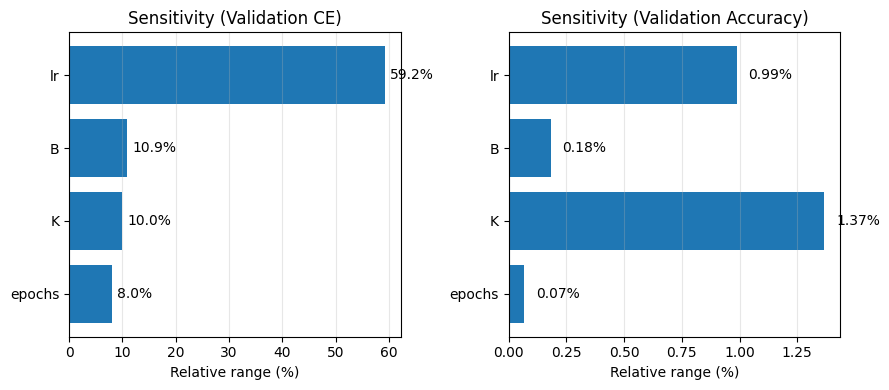

In [ ]:
# Consistent ordering (most important first)
params = ["lr", "B", "K", "epochs"]

# Relative ranges
range_ce  = [59.204434, 10.867156, 9.952915, 7.963173]
range_acc = [0.9887,    0.1815,    1.3674,   0.0678]

fig, axes = plt.subplots(1, 2, figsize=(9, 4))  # slightly smaller width

axes[0].barh(params, range_ce)
axes[0].invert_yaxis()
axes[0].set_title("Sensitivity (Validation CE)")
axes[0].set_xlabel("Relative range (%)")
axes[0].grid(True, axis='x', alpha=0.3)

# Add values
for i, v in enumerate(range_ce):
    axes[0].text(v + 1, i, f"{v:.1f}%", va='center')

axes[1].barh(params, range_acc)
axes[1].invert_yaxis()
axes[1].set_title("Sensitivity (Validation Accuracy)")
axes[1].set_xlabel("Relative range (%)")
axes[1].grid(True, axis='x', alpha=0.3)

# Add values
for i, v in enumerate(range_acc):
    axes[1].text(v + 0.05, i, f"{v:.2f}%", va='center')

plt.tight_layout()
plt.show()
plt.close()

In our experiments, the learning rate showed the largest variation in validation metrics with a relative range of around 59.2%. This indicates that step size had the strongest influence on performance. While batch size, K and number of epochs had comparatively smaller effects sensitivity wise. 

However, the same cannot be said for accuracy. The variation in validation accuracy across hyperparameters was very small (all relative ranges below 1.5%), indicating that accuracy was comparatively insensitive to these tuning choices. This suggests that cross-entropy is a more sensitive metric for detecting meaningful performance differences, while accuracy remains relatively stable once the model reaches a reasonable decision boundary.

Now we can start analyzing (in Task 3) the effects of lambda in L2 regularization with fixed hyperparameters.

# TASK 3: Bias–Variance Trade-Off via λ Sweep (With K-Fold CV)

**K selection & logarithmic λ Sweep** 

For Task 3, we fixed K=6 based on the hyperparameter selection results from Task 2. We chose to perform a logarithmic sweep over λ because regularization effects are highly non-linear and typically vary across several orders of magnitude. A log-scale grid allows fine exploration of very small values (near no regularization) while still covering larger values that may induce underfitting, ensuring that the full bias–variance trade-off is properly captured.

In [110]:
# fixed hyperparameters from assignment 
TASK3_LR = 0.1
TASK3_B  = 16
TASK3_EPOCHS = 200

# i picked best from task 2
K_TASK3 = 6

LAMBDA_GRID = [0.0] + list(np.logspace(-6, 1, num=100)) # used 100 points between 0 and 1e-6 to go further 

In [111]:
def standardize_train_test(X_train, X_test):
    mu = X_train.mean(axis=0)
    sigma = X_train.std(axis=0, ddof=0)
    sigma[sigma == 0] = 1.0
    return (X_train - mu) / sigma, (X_test - mu) / sigma

For each value of λ in the logarithmic grid, we perform K-fold cross-validation (with K=6). Within each fold, the data is standardized using statistics computed only from the training portion of that fold to avoid data leakage. A logistic regression model trained with SGD is then fitted using fixed hyperparameters (learning rate, batch size, and epochs), and the final training and validation cross-entropy and accuracy are recorded. We average these metrics across folds to estimate generalization performance for each λ, and select the best regularization strength as the one minimizing mean validation cross-entropy.

In [112]:
def cv_eval_lambda(X_train_raw, y_train_raw, k, lr, batch_size, epochs, l2, seed=2026):
    X_train_raw = np.asarray(X_train_raw, dtype=np.float64)
    y_train_raw = np.asarray(y_train_raw).astype(int).reshape(-1)

    fold_train_ce, fold_val_ce = [], []
    fold_train_acc, fold_val_acc = [], []

    n = X_train_raw.shape[0]

    for tr_idx, val_idx in kfold_indices(n, k=k, seed=seed, shuffle=True):
        X_tr_raw = X_train_raw[tr_idx]
        y_tr = y_train_raw[tr_idx]
        X_val_raw = X_train_raw[val_idx]
        y_val = y_train_raw[val_idx]

        # fold-wise standardization (fit on train fold only)
        X_tr, X_val = standardize_train_val(X_tr_raw, X_val_raw)

        m = LogisticRegressionSGD(
            lr=lr,
            epochs=epochs,
            batch_size=batch_size,
            l2=l2,
            seed=seed
        )

        # pass val as "test" so we can read m.test_* histories
        m.fit(X_tr, y_tr, X_val, y_val)

        fold_train_ce.append(m.train_ce_history[-1])
        fold_val_ce.append(m.test_ce_history[-1])

        fold_train_acc.append(m.train_acc_history[-1])
        fold_val_acc.append(m.test_acc_history[-1])

    return {
        "K": int(k),
        "lr": float(lr),
        "B": int(batch_size),
        "epochs": int(epochs),
        "lambda": float(l2),

        "train_CE_mean": float(np.mean(fold_train_ce)),
        "train_CE_std":  float(np.std(fold_train_ce, ddof=1)) if k > 1 else 0.0,
        "val_CE_mean":   float(np.mean(fold_val_ce)),
        "val_CE_std":    float(np.std(fold_val_ce, ddof=1)) if k > 1 else 0.0,

        "train_acc_mean": float(np.mean(fold_train_acc)),
        "train_acc_std":  float(np.std(fold_train_acc, ddof=1)) if k > 1 else 0.0,
        "val_acc_mean":   float(np.mean(fold_val_acc)),
        "val_acc_std":    float(np.std(fold_val_acc, ddof=1)) if k > 1 else 0.0,
    }

In [ ]:
task3_results = []
for lam in LAMBDA_GRID:
    res = cv_eval_lambda(
        X_train_raw=X_train_raw,
        y_train_raw=y_train_raw,
        k=K_TASK3,
        lr=TASK3_LR,
        batch_size=TASK3_B,
        epochs=TASK3_EPOCHS,
        l2=lam,
        seed=RANDOM_SEED
    )
    task3_results.append(res)
    print(f"λ={lam:g} | train CE={res['train_CE_mean']:.4f} | val CE={res['val_CE_mean']:.4f} | val acc={res['val_acc_mean']:.4f}")

task3_df = pd.DataFrame(task3_results)

# Table (nice for report)
print("\nTask 3 CV results (mean±std):")
show_cols = ["lambda", "train_CE_mean","train_CE_std","val_CE_mean","val_CE_std","train_acc_mean","val_acc_mean"]
print(task3_df[show_cols].round(4).to_string(index=False))

# pick best lambda by lowest mean validation CE
best_row = task3_df.loc[task3_df["val_CE_mean"].idxmin()]
best_lambda = float(best_row["lambda"])
print(f"\nBest λ by CV (min val CE): λ={best_lambda:g}")
print(best_row[show_cols].round(4).to_string())


λ=0 | train CE=0.0525 | val CE=0.3857 | val acc=0.9128
λ=1e-06 | train CE=0.0525 | val CE=0.3857 | val acc=0.9128
λ=1.17681e-06 | train CE=0.0525 | val CE=0.3857 | val acc=0.9128
λ=1.38489e-06 | train CE=0.0525 | val CE=0.3857 | val acc=0.9128
λ=1.62975e-06 | train CE=0.0525 | val CE=0.3857 | val acc=0.9128
λ=1.91791e-06 | train CE=0.0525 | val CE=0.3857 | val acc=0.9128
λ=2.25702e-06 | train CE=0.0525 | val CE=0.3857 | val acc=0.9128
λ=2.65609e-06 | train CE=0.0525 | val CE=0.3857 | val acc=0.9128
λ=3.12572e-06 | train CE=0.0525 | val CE=0.3857 | val acc=0.9128
λ=3.67838e-06 | train CE=0.0525 | val CE=0.3857 | val acc=0.9128
λ=4.32876e-06 | train CE=0.0525 | val CE=0.3856 | val acc=0.9128
λ=5.09414e-06 | train CE=0.0525 | val CE=0.3856 | val acc=0.9128
λ=5.99484e-06 | train CE=0.0525 | val CE=0.3856 | val acc=0.9128
λ=7.0548e-06 | train CE=0.0525 | val CE=0.3856 | val acc=0.9128
λ=8.30218e-06 | train CE=0.0526 | val CE=0.3856 | val acc=0.9128
λ=9.7701e-06 | train CE=0.0526 | val CE=0.

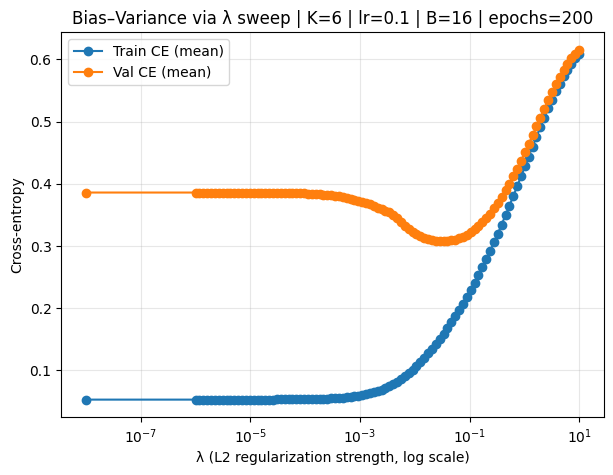

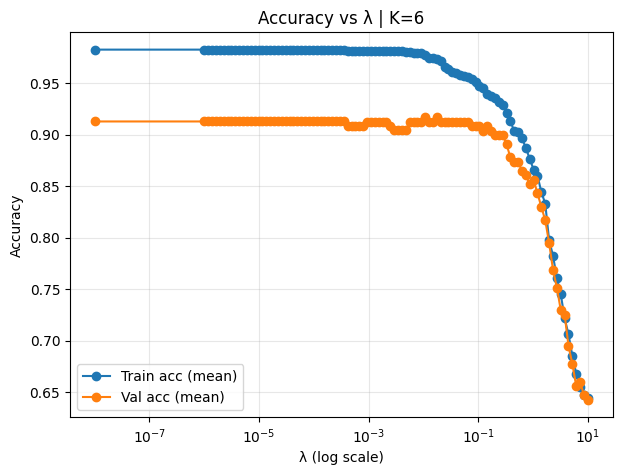

In [114]:
plt.figure(figsize=(7,5))

# avoid log(0): plot lambda=0 at a tiny x value
x = np.array(task3_df["lambda"].values, dtype=float)
x_plot = x.copy()
x_plot[x_plot == 0] = 1e-8

plt.plot(x_plot, task3_df["train_CE_mean"], marker="o", label="Train CE (mean)")
plt.plot(x_plot, task3_df["val_CE_mean"], marker="o", label="Val CE (mean)")

plt.xscale("log")
plt.xlabel("λ (L2 regularization strength, log scale)")
plt.ylabel("Cross-entropy")
plt.title(f"Bias–Variance via λ sweep | K={K_TASK3} | lr={TASK3_LR} | B={TASK3_B} | epochs={TASK3_EPOCHS}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Optional: accuracy plot
plt.figure(figsize=(7,5))
plt.plot(x_plot, task3_df["train_acc_mean"], marker="o", label="Train acc (mean)")
plt.plot(x_plot, task3_df["val_acc_mean"], marker="o", label="Val acc (mean)")
plt.xscale("log")
plt.xlabel("λ (log scale)")
plt.ylabel("Accuracy")
plt.title(f"Accuracy vs λ | K={K_TASK3}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


The λ-sweep clearly illustrates the bias–variance trade-off. For very small λ (weak regularization), training cross-entropy is extremely low while validation cross-entropy remains significantly higher, indicating overfitting (high variance). As λ increases, validation cross-entropy decreases and reaches a minimum at an intermediate value of λ, where generalization is best. Beyond this point, both training and validation cross-entropy increase sharply, showing underfitting due to excessive regularization (high bias).

Our point of interest is the bottom of the validation cross-entropy curve, which corresponds to the optimal balance between bias and variance. This λ achieves the lowest validation loss and therefore represents the best generalization performance according to cross-validation.

In [48]:

# Standardize using ALL TRAIN stats only (no leakage)
Xtr_std, Xte_std = standardize_train_test(
    np.asarray(X_train_raw, dtype=np.float64),
    np.asarray(X_test_raw, dtype=np.float64)
)
ytr = np.asarray(y_train_raw).astype(int).reshape(-1)
yte = np.asarray(y_test_raw).astype(int).reshape(-1)

final_model = LogisticRegressionSGD(
    lr=TASK3_LR,
    epochs=TASK3_EPOCHS,
    batch_size=TASK3_B,
    l2=best_lambda,
    seed=RANDOM_SEED
)
final_model.fit(Xtr_std, ytr, Xte_std, yte)

# Report test metrics
test_ce = final_model.test_ce_history[-1]
test_acc = final_model.test_acc_history[-1]
train_ce = final_model.train_ce_history[-1]
train_acc = final_model.train_acc_history[-1]

print("\nFINAL (retrain on full 5% train, eval on 95% test):")
print(f"Chosen λ = {best_lambda:g}")
print(f"Train: CE={train_ce:.4f}, acc={train_acc:.4f}")
print(f"Test : CE={test_ce:.4f}, acc={test_acc:.4f}")



FINAL (retrain on full 5% train, eval on 95% test):
Chosen λ = 0.033516
Train: CE=0.1671, acc=0.9565
Test : CE=0.3090, acc=0.9048


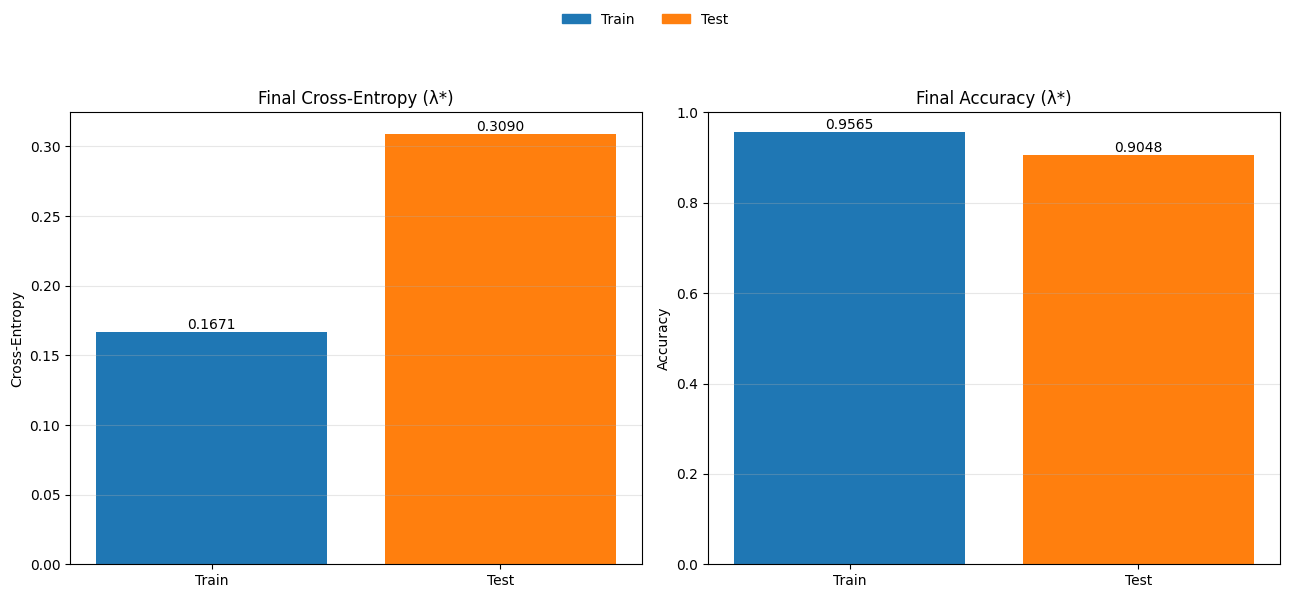

In [ ]:
# Final metrics (λ*)
train_ce  = 0.1671
test_ce   = 0.3090
train_acc = 0.9565
test_acc  = 0.9048

# Colors (explicitly different for Train vs Test)
TRAIN_COLOR = "tab:blue"
TEST_COLOR  = "tab:orange"

fig, axes = plt.subplots(1, 2, figsize=(13,6))

# ---- Plot 1: Cross-Entropy ----
ax = axes[0]
ax.bar(["Train", "Test"], [train_ce, test_ce], color=[TRAIN_COLOR, TEST_COLOR])
ax.set_title("Final Cross-Entropy (λ*)")
ax.set_ylabel("Cross-Entropy")
ax.grid(True, axis="y", alpha=0.3)

# Add value labels
for i, v in enumerate([train_ce, test_ce]):
    ax.text(i, v, f"{v:.4f}", ha="center", va="bottom")

# ---- Plot 2: Accuracy ----
ax = axes[1]
ax.bar(["Train", "Test"], [train_acc, test_acc], color=[TRAIN_COLOR, TEST_COLOR])
ax.set_title("Final Accuracy (λ*)")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.0)
ax.grid(True, axis="y", alpha=0.3)

# Add value labels
for i, v in enumerate([train_acc, test_acc]):
    ax.text(i, v, f"{v:.4f}", ha="center", va="bottom")

# Global legend (one legend for both plots)
handles = [
    plt.Rectangle((0, 0), 1, 1, color=TRAIN_COLOR, label="Train"),
    plt.Rectangle((0, 0), 1, 1, color=TEST_COLOR,  label="Test"),
]
fig.legend(handles=handles, loc="upper center", ncol=2, frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.88])  # leave space for the legend
plt.show()
plt.close()

Therefore, we calculate the best_lambda as the min point on the mean validation CE curve. Using cross-validation, we selected λ*=0.0335 as the optimal regularization strength. Retraining on the full training split and evaluating on the held-out test set yields a test cross-entropy of 0.3090 and test accuracy of 0.9048, confirming strong generalization performance. The gap between training and test metrics reflects mild but controlled overfitting, indicating that the chosen λ achieves a good bias–variance balance.

### **Learning Curves at selected λ***

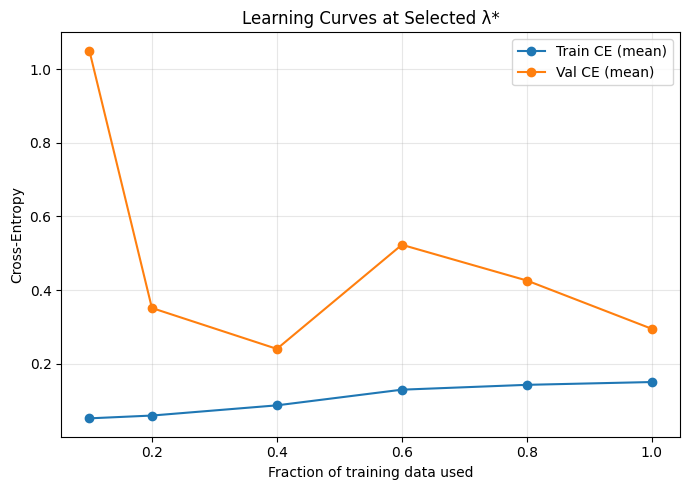

In [ ]:
fractions = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0]
train_ce_list, val_ce_list = [], []

rng = np.random.default_rng(2026)
n = X_train_raw.shape[0]
idx_all = np.arange(n)

for frac in fractions:
    rng.shuffle(idx_all)
    m = int(frac * n)
    sub_idx = idx_all[:m]

    X_sub = X_train_raw[sub_idx]
    y_sub = y_train_raw[sub_idx]

    # simple CV estimate at this training size (keep it fast: K=3)
    res = cv_eval_lambda(
        X_train_raw=X_sub,
        y_train_raw=y_sub,
        k=3,
        lr=TASK3_LR,
        batch_size=TASK3_B,
        epochs=TASK3_EPOCHS,
        l2=best_lambda,        # chosen λ*
        seed=2026
    )

    train_ce_list.append(res["train_CE_mean"])
    val_ce_list.append(res["val_CE_mean"])

plt.figure(figsize=(7,5))
plt.plot(fractions, train_ce_list, marker='o', label="Train CE (mean)")
plt.plot(fractions, val_ce_list, marker='o', label="Val CE (mean)")
plt.xlabel("Fraction of training data used")
plt.ylabel("Cross-Entropy")
plt.title("Learning Curves at Selected λ*")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


This figure shows training and validation cross-entropy as the fraction of training data increases, with λ fixed at the value selected via cross-validation.

For very small datasets, training error is low while validation error is high, indicating a large generalization gap and strong overfitting (high variance). As more data is used, validation error decreases and the gap between training and validation narrows, demonstrating variance reduction.

This confirms that while regularization helps control complexity, increasing dataset size is crucial for improving generalization performance.

# Task 4: L1-Regularized Logistic Regression and the Regularization Path

## 1. Regularization path of coefficients:

In this block, we compute the L1 regularization path by fitting a logistic regression model across a logarithmic grid of regularization strengths C. 

Since C=1/λ, small values of C correspond to strong regularization and promote sparsity, while large values correspond to weaker regularization. 

For each value of C, we store the full coefficient vector, count the number of non-zero coefficients (to measure sparsity), and record training and test performance using both accuracy and cross-entropy. This allows us to later visualize how model sparsity and predictive performance evolve as regularization strength changes.

In [125]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

coef_path = []

n_nonzero = []
n_zero = []

train_acc = []
test_acc = []

train_ce = []
test_ce = []

In [126]:
C_GRID = np.logspace(-4, 4, 30)
for C in C_GRID:
    # TASK REQUIREMENT 1
    model = LogisticRegression(
        # default max iteration is too low (100), so set to 5000
        penalty="l1", solver="saga", C=C, random_state=2026, warm_start=True, max_iter=5000
        )
    model.fit(Xtr_std, ytr)
    coef_path.append(model.coef_[0])
    n_nonzero.append(np.sum(np.abs(model.coef_[0]) > 0))    # Plot 2
    n_zero.append(np.sum(model.coef_[0] == 0))              # Plot 2

    # ABOVE AND BEYOND: look at performance of model on test data as well
    # accuracy:
    train_acc.append(accuracy_score(ytr, model.predict(Xtr_std)))
    test_acc.append(accuracy_score(yte, model.predict(Xte_std)))

    # Cross Entropy loss
    # predicted probabilities
    train_probs = model.predict_proba(Xtr_std)[:, 1]
    test_probs = model.predict_proba(Xte_std)[:, 1]

    # numerical stability (VERY IMPORTANT)
    eps = 1e-15
    train_probs = np.clip(train_probs, eps, 1 - eps)
    test_probs = np.clip(test_probs, eps, 1 - eps)

    # compute CE
    train_loss = -np.mean(
        ytr * np.log(train_probs) +
        (1 - ytr) * np.log(1 - train_probs)
    )

    test_loss = -np.mean(
        yte * np.log(test_probs) +
        (1 - yte) * np.log(1 - test_probs)
    )

    train_ce.append(train_loss)
    test_ce.append(test_loss)


coef_path = np.array(coef_path)  # (30, 57)

From our previously computed data, we can build the various graphs needed to compare and understand the effects of L1 regularization.

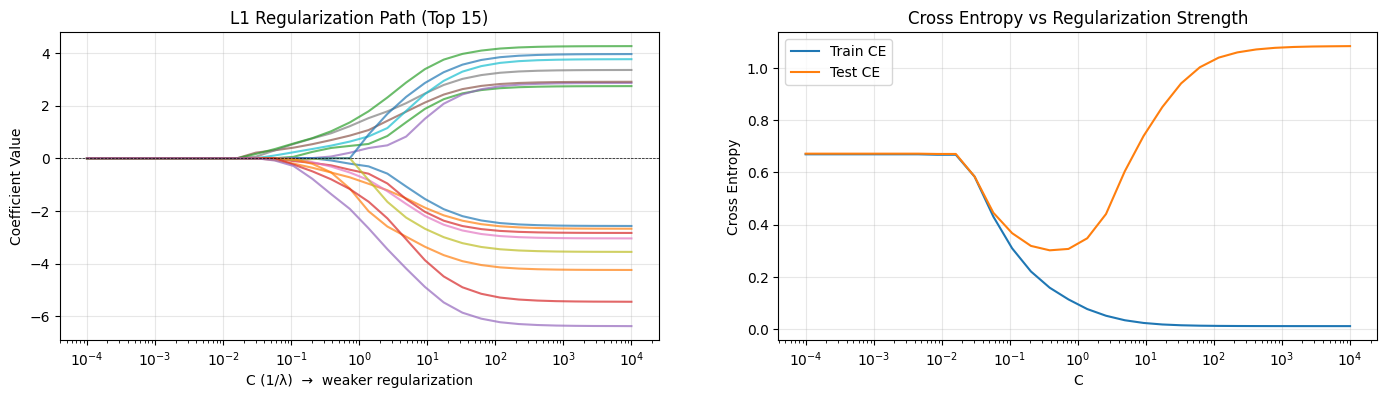

In [134]:
fig, axes = plt.subplots(1, 2,figsize=(17,4))

# L1 Regularization Path
ax1 = axes[0]
top_k = np.argsort(np.max(np.abs(coef_path), axis=0))[-15:]
for j in top_k:
    ax1.plot(C_GRID, coef_path[:, j], alpha=0.7)
ax1.axhline(0, color='k', linewidth=0.5, linestyle='--')
ax1.set_xlabel('C (1/λ)  →  weaker regularization')
ax1.set_ylabel('Coefficient Value')
ax1.set_title('L1 Regularization Path (Top 15)')
ax1.set_xscale('log')
ax1.grid(True, alpha=0.3) 


# cross entropy loss
ax3 = axes[1]

ax3.plot(C_GRID, train_ce, label="Train CE")
ax3.plot(C_GRID, test_ce, label="Test CE")

ax3.set_xscale("log")
ax3.set_xlabel("C")
ax3.set_ylabel("Cross Entropy")
ax3.set_title("Cross Entropy vs Regularization Strength")
ax3.legend()
ax3.grid(True, alpha=0.3)


**L1 Regularization Path**

The regularization path shows how the largest coefficients evolve as regularization weakens (moving right, increasing C). For very small C (strong regularization), nearly all coefficients are exactly zero, indicating a highly sparse model. As C increases, features begin to enter the model gradually, with some coefficients growing faster than others. The order in which coefficients move away from zero reflects their relative importance, since the most informative features become non-zero first. As C increases to a very weak regularization, L1 effectively has no effect and therefore overfitting occurs. 

**CE vs C**

Training cross-entropy decreases continuously as regularization weakens, since the model becomes more flexible and fits the training data more closely. However, test cross-entropy forms a U-shaped curve: it decreases at first (this is as the more informative features appear) but increases again when regularization becomes too weak and the model begins overfitting training data. Therefore, to determine an ideal value for C, we look to find the lowest point on the test CE curve.

## 2. Sparsity plot:

Text(0.5, 1.0, 'Sparsity vs Regularization Strength')

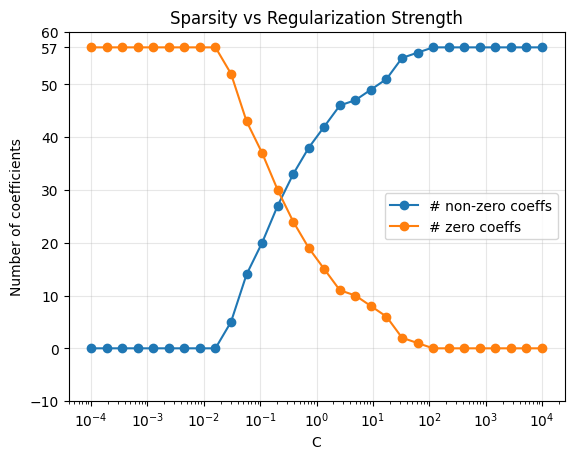

In [65]:
plt.figure()
plt.plot(C_GRID, n_nonzero, marker='o', label = "# non-zero coeffs")
plt.plot(C_GRID, n_zero, marker='o', label = "# zero coeffs")
plt.xscale('log')
plt.xlabel('C')
plt.ylabel('Number of coefficients')

# add 57 to y axis for better visualization
yaxis = list(plt.yticks()[0])
yaxis.append(57) 
plt.yticks(sorted(yaxis))

plt.legend()
plt.grid(True, alpha=0.3)
plt.title('Sparsity vs Regularization Strength')

**Sparsity plot**

This sparsity plot confirms our previous analysis. When C is very big (and regularization very weak) all features are included which leads to overfitting. And, when C is very small (and regularization is strong), all features have coefficients of zero. 

In fact, by comparing the 3 curves the ideal value for C is in the range [10^-1, 10^0]. This is in the range of the intersection of the curves on the sparsity plot, as well as at the min point on the test CE curve. However, in practice we cannot select C by minimizing the CE for our test data because those values in pratice would not be available, and if we do that now we would introduce leakage. This would bias our model towards our data. 

## 3. CV performance vs Regularization Strength

In an ideal world, we would be able to select C by analyzing the test performance for all values of C. But, as described previously this would introduce leakage. Therefore, we must look into finding a metric that estimates test performance by only introducing our training data. These conditions are ideal for the use of Cross Validation across our training data.

The two ways in which can accurately compare and analyze performance is by looking into **mean validated Accuracy** and **mean validated Cross Entropy**.

For the CV performance, k=10 was selected because it is a commonly recommended value for the number of folds. 

#### CV Mean Accuracy vs Regularization

In [ ]:
from sklearn.linear_model import LogisticRegressionCV

# k fold CV model - commonly recommended value 
k = 10

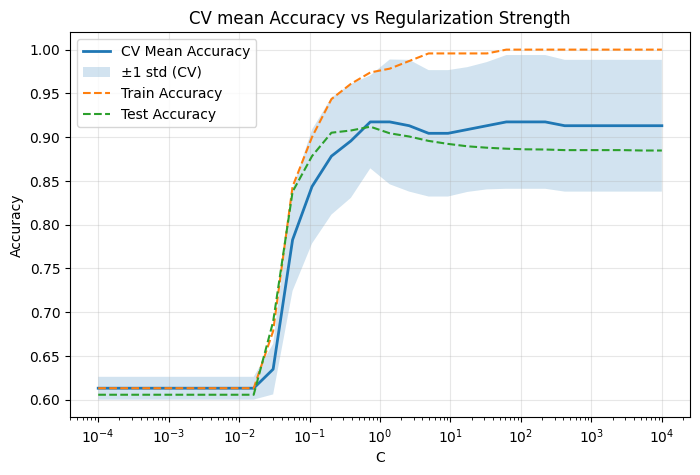

In [ ]:
cv_model = LogisticRegressionCV(
    Cs=C_GRID, penalty='l1', solver='saga',
    max_iter=5000, random_state=2026, cv=k
    )

cv_model.fit(Xtr_std, ytr)

# mean CV scores across folds for each C
mean_scores = cv_model.scores_[1].mean(axis=0)  # shape (30,)
std_scores = cv_model.scores_[1].std(axis=0)

train_scores = []
test_scores = []

for C in C_GRID:
    model = LogisticRegression(
        penalty='l1',
        solver='saga',
        C=C,
        max_iter=5000,
        random_state=2026
    )
    model.fit(Xtr_std, ytr)

    train_scores.append(model.score(Xtr_std, ytr))
    test_scores.append(model.score(Xte_std, yte))

plt.figure(figsize=(8,5))

plt.plot(C_GRID, mean_scores, label="CV Mean Accuracy", linewidth=2)
plt.fill_between(
    C_GRID,
    mean_scores - std_scores,
    mean_scores + std_scores,
    alpha=0.2,
    label="±1 std (CV)"
)

plt.plot(C_GRID, train_scores, linestyle="--", label="Train Accuracy")
plt.plot(C_GRID, test_scores, linestyle="--", label="Test Accuracy")

plt.xscale("log")
plt.xlabel("C")
plt.ylabel("Accuracy")
plt.title("CV mean Accuracy vs Regularization Strength")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



**CV mean Accuracy vs C**

The mean cross-validation (CV) accuracy curve is the primary tool used to select the optimal regularization strength C. Unlike the training curve, which reflects fit on seen data, and the test curve, which must not be used for tuning, the CV mean provides an unbiased estimate of generalization performance by averaging results across multiple folds. The fact that the CV curve closely tracks the test accuracy curve is important: it confirms that cross-validation is providing a reliable estimate. The optimal C is therefore chosen at the peak of the mean CV curve, where validation performance is maximized while avoiding overfitting at large C. However, it is not clear where the true maximum value lies on the CV mean accuracy curve. That means we could select a C around 10^0 or one around 10^2. 

Since this creates a large error, a better performance metric can be used. I am talking about looking into CV mean Cross-Entropy instead.

#### CV Mean Cross-Entropy vs Regularization

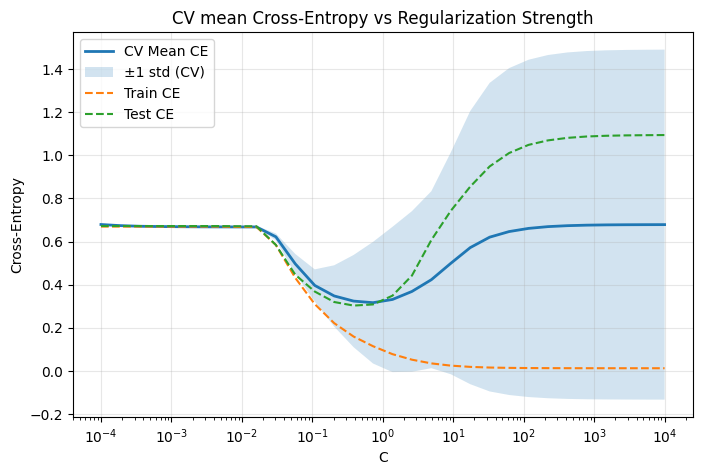

In [84]:
from sklearn.metrics import log_loss


cv_model = LogisticRegressionCV(
    Cs=C_GRID,
    penalty='l1',
    solver='saga',
    max_iter=5000,
    random_state=2026,
    cv=k,
    scoring="neg_log_loss"   # IMPORTANT
)

cv_model.fit(Xtr_std, ytr)

# CV log-loss is stored as negative values
mean_ce = -cv_model.scores_[1].mean(axis=0)
std_ce = cv_model.scores_[1].std(axis=0)


train_ce = []
test_ce = []

for C in C_GRID:
    model = LogisticRegression(
        penalty='l1',
        solver='saga',
        C=C,
        max_iter=5000,
        random_state=2026
    )
    model.fit(Xtr_std, ytr)

    train_probs = model.predict_proba(Xtr_std)[:, 1]
    test_probs  = model.predict_proba(Xte_std)[:, 1]

    train_ce.append(log_loss(ytr, train_probs))
    test_ce.append(log_loss(yte, test_probs))

plt.figure(figsize=(8,5))

plt.plot(C_GRID, mean_ce, label="CV Mean CE", linewidth=2)
plt.fill_between(
    C_GRID,
    mean_ce - std_ce,
    mean_ce + std_ce,
    alpha=0.2,
    label="±1 std (CV)"
)

plt.plot(C_GRID, train_ce, linestyle="--", label="Train CE")
plt.plot(C_GRID, test_ce, linestyle="--", label="Test CE")

plt.xscale("log")
plt.xlabel("C")
plt.ylabel("Cross-Entropy")
plt.title("CV mean Cross-Entropy vs Regularization Strength")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**CV Mean Cross-Entropy vs Regularization Strength**

The mean CV cross-entropy curve shows a clear minimum at an intermediate value of C, making it easier to identify the optimal regularization strength. Unlike accuracy, which can plateau and hide subtle overfitting effects, cross-entropy is more sensitive to confidence in predictions and therefore provides a sharper selection criterion. The CV mean CE closely follows the test CE curve, confirming that cross-validation reliably estimates true generalization performance.

In [89]:
# SELECT BEST L1 MODEL (by MIN mean CV cross-entropy)
best_C_idx = np.argmin(mean_ce)
best_C_l1 = C_GRID[best_C_idx]

print(f"Best C (L1): {best_C_l1:.6g}  →  λ = {1/best_C_l1:.6g}")
print(f"Mean CV CE at best C: {mean_ce[best_C_idx]:.4f}  (lower is better)")
print(f"Std  CV CE at best C: {std_ce[best_C_idx]:.4f}")

# Coefficient info at best C (from your coef_path array)
best_coefs = coef_path[best_C_idx]
nonzero_mask = best_coefs != 0
zero_mask = ~nonzero_mask

print(f"\nNon-zero coefficients: {nonzero_mask.sum()} / 57")
print(f"Zeroed-out features:   {zero_mask.sum()} / 57")

# Load feature names (spambase.names includes a final "class" line -> drop it)
feature_names = (
    pd.read_csv("spambase.names", comment="|", header=None)[0]
      .str.split(":", n=1).str[0]
      .dropna()
      .tolist()
)

# Keep only the 57 feature names (drop any trailing label line if present)
feature_names = np.array(feature_names[:57])

print("\nRemoved features (coefficient = 0):")
for name in feature_names[zero_mask]:
    print(f"  - {name}")

Best C (L1): 0.727895  →  λ = 1.37382
Mean CV CE at best C: 0.3162  (lower is better)
Std  CV CE at best C: 0.2823

Non-zero coefficients: 38 / 57
Zeroed-out features:   19 / 57

Removed features (coefficient = 0):
  - word_freq_all
  - word_freq_internet
  - word_freq_will
  - word_freq_people
  - word_freq_report
  - word_freq_free
  - word_freq_email
  - word_freq_george
  - word_freq_650
  - word_freq_telnet
  - word_freq_data
  - word_freq_415
  - word_freq_1999
  - word_freq_meeting
  - word_freq_table
  - char_freq_;
  - char_freq_(
  - char_freq_#
  - capital_run_length_average


In [117]:
# --- Identify most important features (by absolute coefficient magnitude) ---
# Absolute magnitude
abs_coefs = np.abs(best_coefs)

# Sort indices by descending importance
sorted_idx = np.argsort(abs_coefs)[::-1]

print("\nTop 10 most important features (by |coefficient|):\n")

for i in sorted_idx[:10]:
    print(f"{feature_names[i]:<20}  coef = {best_coefs[i]:>8.4f}")


Top 10 most important features (by |coefficient|):

word_freq_money       coef =  -1.9225
char_freq_[           coef =   1.3588
word_freq_over        coef =   1.2163
word_freq_re          coef =  -1.1692
word_freq_hpl         coef =  -1.1502
char_freq_!           coef =   0.8589
word_freq_technology  coef =  -0.7248
word_freq_font        coef =   0.6452
word_freq_business    coef =   0.6324
word_freq_cs          coef =  -0.5422


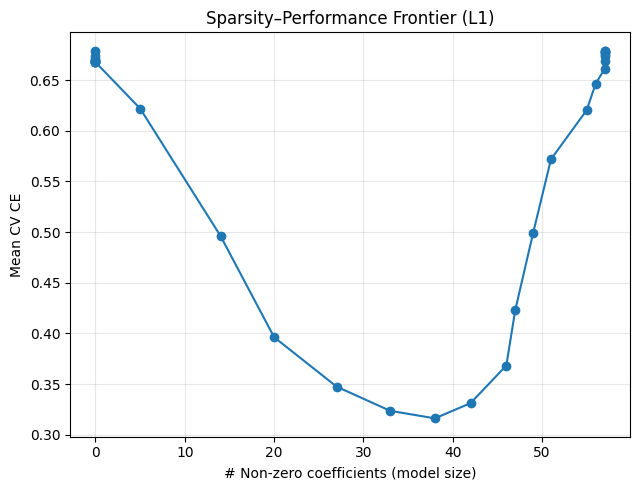

In [122]:
# After you compute:
# n_nonzero (len 30) from the path loop
# mean_scores (len 30) from LogisticRegressionCV



plt.figure(figsize=(6.5, 5))
plt.plot(n_nonzero, mean_ce, marker='o')
plt.xlabel("# Non-zero coefficients (model size)")
plt.ylabel("Mean CV CE")
plt.title("Sparsity–Performance Frontier (L1)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
#plt.savefig(fr"{out_dir}\sparisty_l1.png", dpi=300)
plt.show()


**Final Statement on L1 Regularization Results**

Using cross-validated cross-entropy, the optimal regularization strength was found at C≈0.73. At this level of regularization, the model retains 38 out of 57 features, meaning 19 features were automatically removed. This confirms the sparsity-inducing property of L1 regularization: it performs built-in feature selection while maintaining strong predictive performance.

Importantly, when we compare the removed features with the earlier correlation heatmap, we observe that some of the highly correlated variables (e.g., word_freq_650, word_freq_415) were eliminated. These features were part of strongly correlated clusters, indicating multicollinearity. L1 regularization tends to keep only one representative feature from such correlated groups while shrinking the others exactly to zero. This behavior improves model interpretability and reduces redundancy without significantly harming performance.

Overall, the results demonstrate that L1 regularization not only balances bias and variance but also mitigates multicollinearity by selecting a sparse and more interpretable subset of features.

## 4. Comparing L1 and L2 Regularization

To go beyond coefficient paths and cross-validation metrics, we now directly compare the final L1 and L2 models on the test set. While L1 promotes sparsity and L2 shrinks coefficients smoothly, both aim to improve generalization. Therefore, it is important to evaluate them using performance metrics that capture classification quality across decision thresholds.

We compare the models using ROC curves and AUC, which show how well each model can separate spam from non-spam across all possible classification thresholds. We also use confusion matrices. Which by counting the number of true positives/negatives & false positives/negatives produced by each model’s prediction, we can understand the type of mistakes made by that model. Since the dataset has a roughly 39.4/60.6 class split, precision-recall analysis is less infomative as there is little class imbalance.

This comparison allows us to assess whether the sparsity induced by L1 leads to comparable predictive performance relative to L2, and whether either regularization method provides superior generalization on unseen data.

In [93]:
# Proportion of each class in the full dataset
unique, counts = np.unique(y, return_counts=True)
proportions = counts / len(y)

for cls, count, prop in zip(unique, counts, proportions):
    label = "Spam (1)" if cls == 1 else "Not Spam (0)"
    print(f"{label}: {count} samples ({prop:.2%})")

Not Spam (0): 2788 samples (60.60%)
Spam (1): 1813 samples (39.40%)


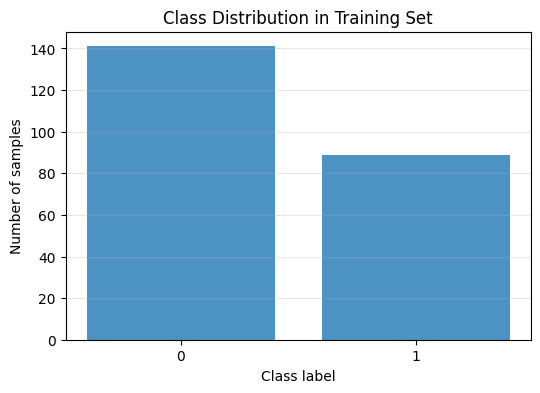

Class 0: 141 samples (61.304%)
Class 1: 89 samples (38.696%)


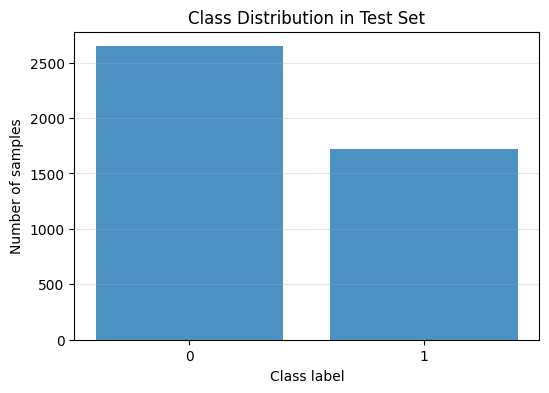

In [118]:
# --- Class imbalance visualization ---
unique, counts = np.unique(ytr, return_counts=True)

plt.figure(figsize=(6,4))
plt.bar(unique.astype(str), counts, alpha=0.8)
plt.xlabel("Class label")
plt.ylabel("Number of samples")
plt.title("Class Distribution in Training Set")
plt.grid(axis='y', alpha=0.3)
plt.show()

# Print proportions
total = counts.sum()
for u, c in zip(unique, counts):
    print(f"Class {u}: {c} samples ({c/total:.3%})")
unique_te, counts_te = np.unique(yte, return_counts=True)

plt.figure(figsize=(6,4))
plt.bar(unique_te.astype(str), counts_te, alpha=0.8)
plt.xlabel("Class label")
plt.ylabel("Number of samples")
plt.title("Class Distribution in Test Set")
plt.grid(axis='y', alpha=0.3)
plt.show()

In order to compare L1 and L2 models fairly we use the **best models** found for both regularization methods. 

In [90]:
# Retrain on ALL training data with best C
best_l1 = LogisticRegression(
    penalty='l1', solver='saga', C=best_C_l1,
    random_state=2026, max_iter=5000
)
best_l1.fit(Xtr_std, ytr)

# we already found best l2 regularization strength in task 3: λ=0.033516
# best hyperparameters (task 2)
# K=6 | B=50, lr=0.01, epochs=250, val_CE=0.3173, val_acc=0.9127
# Retrain final L2 model on full training data (same as Task 3)
best_l2 = LogisticRegressionSGD(
    lr=TASK3_LR,
    epochs=TASK3_EPOCHS,
    batch_size=TASK3_B,
    l2=best_lambda,
    seed=RANDOM_SEED
)
best_l2.fit(Xtr_std, ytr)

# Get predictions from your custom L2 SGD model
l2_probs = best_l2.predict_proba(Xte_std)   # shape (n,) — probabilities
l2_preds = best_l2.predict(Xte_std)          # shape (n,) — binary predictions

# Get predictions from best L1 sklearn model
l1_probs = best_l1.predict_proba(Xte_std)[:, 1]
l1_preds = best_l1.predict(Xte_std)





In [135]:
from sklearn.metrics import (
    roc_curve, auc,
    confusion_matrix
)

# --- Predicted probabilities ---
l1_probs = best_l1.predict_proba(Xte_std)[:, 1] 
l2_probs = best_l2.predict_proba(Xte_std)        
l1_preds = best_l1.predict(Xte_std)
l2_preds = best_l2.predict(Xte_std)

# --- ROC curves ---
l1_fpr, l1_tpr, _ = roc_curve(yte, l1_probs)
l2_fpr, l2_tpr, _ = roc_curve(yte, l2_probs)
l1_auc = auc(l1_fpr, l1_tpr)
l2_auc = auc(l2_fpr, l2_tpr)

# --- Confusion matrices ---
cm_l1 = confusion_matrix(yte, l1_preds)
cm_l2 = confusion_matrix(yte, l2_preds)

**GENERATION OF ALL PLOTS**

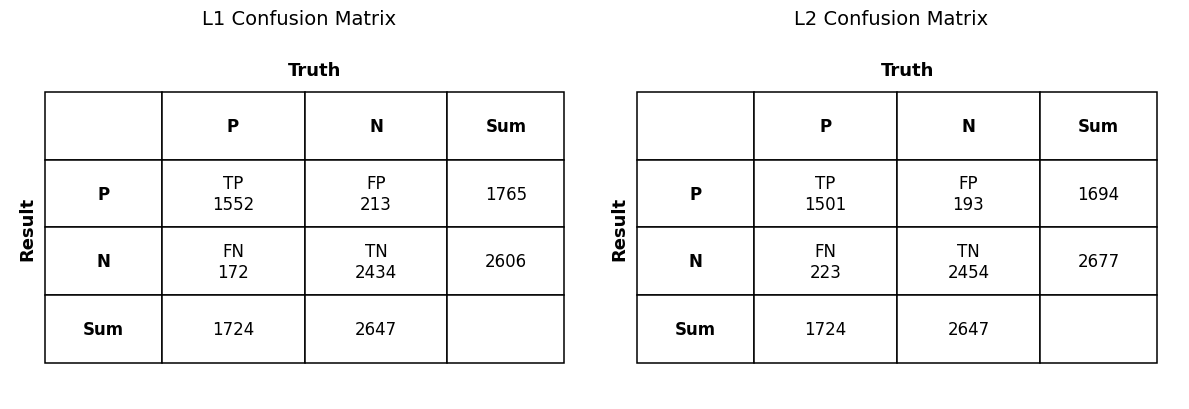

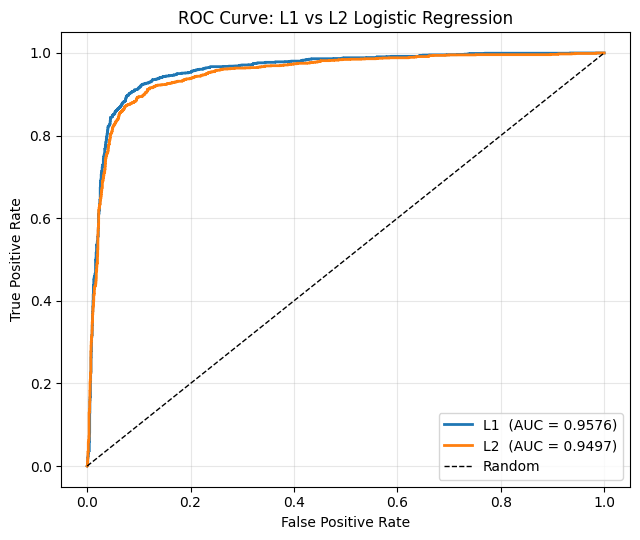


=== Final Performance Comparison ===
Metric                            L1 (sklearn)        L2 (SGD)
------------------------------------------------------------
Best C (L1)                             0.7279             N/A
Best λ (L2)                                N/A          0.0335
Non-zero coefficients                       38      57 (dense)
Test Accuracy                           0.9119          0.9048
ROC AUC                                 0.9576          0.9497


In [ ]:
def plot_cm_table_nice(ax, cm, title):
    tn, fp = cm[0, 0], cm[0, 1]
    fn, tp = cm[1, 0], cm[1, 1]

    P  = tp + fn
    N  = tn + fp
    RP = tp + fp
    RN = tn + fn

    cell_text = [
        ["",   "P",         "N",         "Sum"],
        ["P",  f"TP\n{tp}", f"FP\n{fp}", f"{RP}"],
        ["N",  f"FN\n{fn}", f"TN\n{tn}", f"{RN}"],
        ["Sum", f"{P}",      f"{N}",      ""],
    ]

    ax.axis("off")

    # bbox of the table inside this axis: [left, bottom, width, height]
    bbox = [0.06, 0.10, 0.90, 0.75]
    left, bottom, width, height = bbox

    table = ax.table(
        cellText=cell_text,
        cellLoc="center",
        loc="center",
        colWidths=[0.18, 0.22, 0.22, 0.18],
        bbox=bbox,
    )
    table.auto_set_font_size(False)
    table.set_fontsize(12)

    for (r, c), cell in table.get_celld().items():
        cell.set_edgecolor("black")
        cell.set_linewidth(1.1)
        if r == 0 or c == 0:
            cell.set_text_props(weight="bold")

    # "Truth" centered above the P/N columns
    ax.text(left + width*0.52, bottom + height + 0.06,
            "Truth", ha="center", va="center",
            fontsize=13, fontweight="bold")

    # "Result" vertically centered over the two result rows (P and N)
    # Rows in table: header (row0) + P (row1) + N (row2) + Sum (row3)
    # So P+N rows occupy 2/4 of table height, starting after header row.
    y_center_results = bottom + height * (0.5)  # center of the whole table
    # but shift slightly upward because "Sum" row is below results
    # Exact: center of rows 1 and 2 => midpoint of [row1,row2]
    # Header=1/4, P=1/4, N=1/4, Sum=1/4 => center of P+N is at 1/4 + 1/4 = 1/2
    y_center_results = bottom + height * 0.50

    ax.text(left - 0.03, y_center_results,
            "Result", ha="center", va="center",
            rotation=90, fontsize=13, fontweight="bold")

    ax.set_title(title, fontsize=14, pad=10)


fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
plot_cm_table_nice(axes[0], cm_l1, "L1 Confusion Matrix")
plot_cm_table_nice(axes[1], cm_l2, "L2 Confusion Matrix")
plt.tight_layout()
plt.show()


plt.figure(figsize=(6.5, 5.5))

# L1 ROC
plt.plot(l1_fpr, l1_tpr, linewidth=2,
         label=f"L1  (AUC = {l1_auc:.4f})")

# L2 ROC
plt.plot(l2_fpr, l2_tpr, linewidth=2,
         label=f"L2  (AUC = {l2_auc:.4f})")

# Random classifier
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: L1 vs L2 Logistic Regression")

plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n=== Final Performance Comparison ===")
print(f"{'Metric':<30} {'L1 (sklearn)':>15} {'L2 (SGD)':>15}")
print("-" * 60)
print(f"{'Best C (L1)':<30} {best_C_l1:>15.4f} {'N/A':>15}")
print(f"{'Best λ (L2)':<30} {'N/A':>15} {best_lambda:>15.4f}")
print(f"{'Non-zero coefficients':<30} {np.sum(best_l1.coef_[0] != 0):>15} {'57 (dense)':>15}")
print(f"{'Test Accuracy':<30} {accuracy_score(yte, l1_preds):>15.4f} {accuracy_score(yte, l2_preds):>15.4f}")
print(f"{'ROC AUC':<30} {l1_auc:>15.4f} {l2_auc:>15.4f}")


**Final statement on L1 vs L2 regularization**

Overall, the ROC curves show that both L1 and L2 achieve very strong discriminative performance, with AUC values of 0.9576 (L1) and 0.9497 (L2). The curves almost overlap, indicating that both models separate spam from non-spam very effectively across all thresholds. L1 is slightly higher, but the difference is small and unlikely to be practically significant.

Looking at the confusion matrices, the models also behave very similarly at the default 0.5 threshold. L1 produces slightly more true positives (1552 vs 1501) and fewer false negatives (172 vs 223), meaning it catches more spam. L2, on the other hand, produces slightly fewer false positives (193 vs 213), meaning it is slightly more conservative in labeling emails as spam. However, these differences are modest, and overall test accuracy is nearly identical (≈0.912 vs ≈0.905).

Since performance metrics (accuracy, AUC, PR AUC) are very close, we cannot definitively claim one model is strictly better in predictive power. The key difference lies in model structure: L1 achieves comparable performance while using only 38 non-zero features (sparse), whereas L2 keeps all 57 features (dense). Therefore, in this case, L1 may be preferable for interpretability and feature selection, while L2 provides similar performance without enforcing sparsity.